In [ ]:
## NOTE: most of the content of this notebook was generated by AI ##
## I wrote some comments explaining what's going on in this task
## these comments are preceeded by a <HUMAN WRITTEN COMMENTS> flag, you can just CTRL+F with this flag to jump to these comments

## I Avoided explaining anything related to the golden rule since i explained it in details in assignment 2 
## Rather, I focused on explaining things related to kernels and feature maps as well as finetuning


# 🧠 Image Classification Lab — MLP → CNN → Transfer Learning

**Dataset**: CIFAR-10 (via `torchvision`) — 10 classes, 32×32 RGB images  
**Pretrained Model**: ResNet-34 (ImageNet weights, finetuned on CIFAR-10)  
**Framework**: PyTorch  

---

## 📌 Domain Investigation

### Model Domain (What ResNet was designed for)
ResNet-34 was originally designed and trained on **ImageNet** — a large-scale dataset of ~1.2M images across **1000 classes**, with images typically resized to **224×224 pixels**. The architecture is built around **residual connections** (skip connections) that solve the vanishing gradient problem, enabling training of very deep networks. The network learns a hierarchy of features: edges → textures → object parts → full objects.

### Dataset Domain (CIFAR-10)
**CIFAR-10** contains **60,000 color images** (50K train / 10K test) across **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Images are only **32×32 pixels** — tiny compared to ImageNet. This is a well-studied benchmark with known difficulty (~95% accuracy is considered excellent). Classes are mutually exclusive and roughly balanced.

### Domain Gap & Key Challenges
- **Resolution mismatch**: ResNet expects 224×224 — we must upsample 32×32 images or adapt the first conv layer
- **Class count mismatch**: ResNet's final FC layer outputs 1000 logits — we replace it with 10
- **Distribution shift**: ImageNet images are high-res natural photographs; CIFAR-10 images are low-res thumbnails
- **For MLP**: Flattening 32×32×3 = 3072 features — spatial structure is completely lost, which hurts performance badly
- **Lazy Loading**: CIFAR-10 fits in RAM easily, but we still use `DataLoader` with batching to simulate production-grade pipelines and demonstrate the lazy loading pattern

---

## 📦 Setup & Imports

In [25]:
# ─────────────────────────────────────────────────────────────
# Core imports — PyTorch ecosystem + visualization
# ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json
import copy
import random
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# Reproducibility — fix all random seeds so experiments
# are deterministic and comparable across runs
# ─────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─────────────────────────────────────────────────────────────
# Device selection — use GPU if available (much faster for CNNs)
# On Google Colab: Runtime → Change runtime type → GPU
# ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ─────────────────────────────────────────────────────────────
# Global constants — centralized for easy tuning
# ─────────────────────────────────────────────────────────────
NUM_CLASSES  = 10
BATCH_SIZE   = 64         # Standard batch size — balance between speed & gradient stability
NUM_WORKERS  = 2          # Parallel data loading workers (set to 0 on Windows if issues)

# CIFAR-10 class names (in label index order)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Training history store — all runs saved here for final comparison plots
ALL_HISTORIES = {}

print('\n✅ Setup complete.')

🖥️  Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

✅ Setup complete.


## 🗂️ Data Loading with Lazy Loading Pattern

> **Lazy Loading** means we never load the entire dataset into memory at once. Instead, `DataLoader` loads mini-batches **on demand** during iteration. Each `__getitem__` call in the Dataset reads just one sample from disk (or memory) and applies transforms only when needed. This is the standard production pattern for large datasets that don't fit in RAM (e.g., ImageNet, medical imaging). For CIFAR-10 it's not strictly necessary, but the code structure is identical to what you'd use for a 100GB dataset.

In [26]:
# ─────────────────────────────────────────────────────────────
# Transform pipelines
#
# CIFAR-10 mean/std are pre-computed statistics of the training set.
# Normalization is CRUCIAL — it puts activations in a good range
# for gradient flow and speeds up convergence significantly.
#
# We define TWO transform pipelines:
#   1. basic_transform  — for MLP and baseline CNN (no augmentation)
#   2. augment_transform — for regularized CNN (data augmentation = free regularization)
# ─────────────────────────────────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Augmentation: random horizontal flip + small random crop
# These preserve label semantics (a flipped cat is still a cat)
# and act as strong regularizers by making the model invariant to
# position/orientation shifts — effectively multiplying dataset size
augment_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # Random crop with 4px zero-padding
    transforms.RandomHorizontalFlip(p=0.5),        # Horizontal mirror with 50% probability
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),        # Slight color perturbations for robustness
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ResNet expects 224×224 — we upsample CIFAR-10's 32×32
# Bilinear interpolation is smooth and works well for small→large upsampling
resnet_transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats (used during pretraining)
                         std= [0.229, 0.224, 0.225]),  # MUST match pretraining normalization!
])

resnet_transform_val = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

print('✅ Transforms defined.')

✅ Transforms defined.


In [27]:
# ─────────────────────────────────────────────────────────────
# Download CIFAR-10 and build DataLoaders
#
# torchvision.datasets.CIFAR10 implements the Dataset interface:
#   __len__()      → number of samples
#   __getitem__(i) → (image_tensor, label) for sample i
# DataLoader wraps it and yields batches lazily — this IS lazy loading.
# For a disk-based dataset you'd use ImageFolder or a custom Dataset.
#
# We use a 10% SAMPLE of training data to keep experiments fast.
# We stratify manually (take equal count per class) to avoid bias.
# ─────────────────────────────────────────────────────────────

def get_stratified_indices(dataset, fraction=0.10):
    """Return indices for a stratified random subset.
    
    Stratification ensures each class is equally represented in the
    sample — prevents accidentally over/under-sampling any class,
    which would bias model training and evaluation.
    """
    targets = np.array(dataset.targets)
    selected = []
    for cls in range(NUM_CLASSES):
        cls_idx = np.where(targets == cls)[0]
        n = max(1, int(len(cls_idx) * fraction))
        chosen = np.random.choice(cls_idx, n, replace=False)
        selected.extend(chosen.tolist())
    random.shuffle(selected)
    return selected


def make_loaders(train_transform, val_transform, fraction=1.0, batch_size=BATCH_SIZE):
    """Build train/val/test DataLoaders with given transforms and sample fraction."""
    full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=train_transform)
    test_ds    = torchvision.datasets.CIFAR10(root='./data', train=False,
                                               download=True, transform=val_transform)
    if fraction < 1.0:
        idx = get_stratified_indices(full_train, fraction)
        full_train = Subset(full_train, idx)

    # 80/20 train-val split
    n_train = int(0.8 * len(full_train))
    n_val   = len(full_train) - n_train
    train_ds, val_ds = torch.utils.data.random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader


# ── Standard loaders (10% sample for speed) ──────────────────
train_loader, val_loader, test_loader = make_loaders(
    basic_transform, basic_transform, fraction=0.10
)

# Augmented loaders (for regularized CNN)
aug_train_loader, aug_val_loader, aug_test_loader = make_loaders(
    augment_transform, basic_transform, fraction=0.10
)

# ResNet loaders (upsample to 224 — needed for pretrained weights)
resnet_train_loader, resnet_val_loader, resnet_test_loader = make_loaders(
    resnet_transform_train, resnet_transform_val, fraction=0.10, batch_size=32
)

print(f'\n📊 Dataset splits (10% sample):')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')


📊 Dataset splits (10% sample):
   Train batches : 63
   Val batches   : 16
   Test batches  : 157


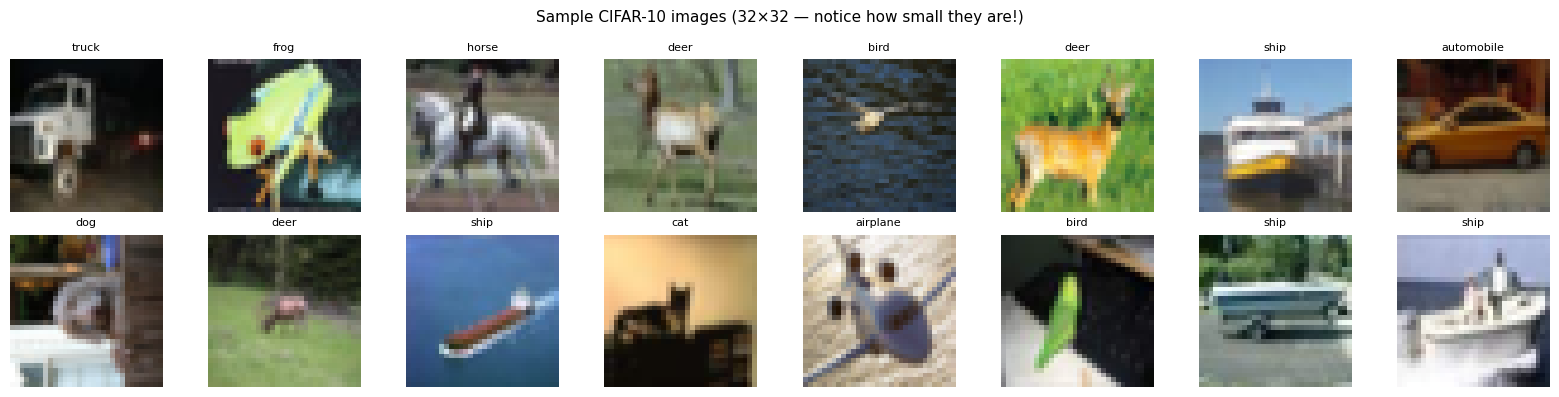

NOTE: These tiny 32×32 images are why MLPs struggle — there's very little spatial context.


In [28]:
# ─────────────────────────────────────────────────────────────
# Visualize sample images — always a good sanity check!
# Seeing the data helps spot normalization issues, label errors,
# or augmentation artifacts early.
# ─────────────────────────────────────────────────────────────
def denormalize(tensor, mean=CIFAR_MEAN, std=CIFAR_STD):
    """Reverse normalization for display — convert standardized tensor back to [0,1]."""
    mean = torch.tensor(mean).view(3,1,1)
    std  = torch.tensor(std).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 images (32×32 — notice how small they are!)', fontsize=11)
plt.tight_layout()
plt.show()
print('NOTE: These tiny 32×32 images are why MLPs struggle — there\'s very little spatial context.')

## 🛠️ Training Infrastructure

We build a reusable training engine once and use it for all experiments.

In [29]:
# ─────────────────────────────────────────────────────────────
# Generic training engine
#
# Design philosophy:
#   - One function handles all models (MLP, CNN, ResNet)
#   - Records loss + accuracy per epoch for both train and val
#   - Saves best model weights by validation loss (early stopping proxy)
#   - Gradient clipping prevents exploding gradients (important for deep nets)
# ─────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, clip_grad=None):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()          # Clear accumulated gradients
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels)  # Compute cross-entropy loss
        loss.backward()               # Backpropagate gradients

        if clip_grad:                  # Optional gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()              # Update weights

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()  # Disable gradient computation for inference (saves memory + speeds up)
def evaluate(model, loader, criterion):
    """Evaluate model on a loader. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, criterion,
                num_epochs=20, scheduler=None, clip_grad=None,
                verbose=True, experiment_name='model'):
    """
    Full training loop with validation monitoring.

    Returns history dict with train/val loss and accuracy per epoch.
    Saves the best model checkpoint (by validation loss).
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer,
                                       criterion, clip_grad)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if scheduler:
            scheduler.step()  # Adjust learning rate per schedule

        # Save best checkpoint — we'll restore this after training
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = copy.deepcopy(model.state_dict())

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'  Epoch {epoch:3d}/{num_epochs} | '
                  f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
                  f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}')

    model.load_state_dict(best_weights)  # Restore best weights
    ALL_HISTORIES[experiment_name] = history
    return history


def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot — gap between train and val indicates overfitting
    ax1.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy plot — ideal: both curves rise, stay close
    ax2.plot(epochs, history['train_acc'], 'b-o', ms=3, label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   'r-o', ms=3, label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print('✅ Training infrastructure ready.')

✅ Training infrastructure ready.


---
# PART 1 — MLP on Image Classification

> **What to expect**: A Multi-Layer Perceptron treats each image as a flat vector of pixel values. By flattening 32×32×3 = **3072 features**, we destroy all spatial structure. The model has no concept of locality — a pixel in the top-left corner is treated as completely independent from its neighbor. This is a fundamental architectural mismatch for images.
>
> Expected accuracy ceiling: **~50-55%** on CIFAR-10 (compared to ~95% for CNNs). This is intentional — it establishes why CNNs exist.

In [30]:
# ─────────────────────────────────────────────────────────────
# MLP Architecture
#
# Three fully-connected layers with ReLU activations and Dropout.
# Batch Normalization accelerates training by normalizing layer inputs.
#
# Input:  3072 (flattened 32×32×3)
# Hidden: 512 → 256
# Output: 10 (class logits)
# ─────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dims=[512, 256], num_classes=10, dropout=0.4):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),   # BN before activation — normalizes pre-activations
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),     # Dropout: randomly zero out neurons to prevent co-adaptation
            ]
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))  # No softmax — CrossEntropyLoss handles it
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten: (B, 3, 32, 32) → (B, 3072)
        return self.net(x)

# Quick parameter count helper
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLP().to(DEVICE)
print(f'MLP parameters: {count_params(mlp):,}')
print(mlp)

MLP parameters: 1,708,810
MLP(
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)


### 🧪 Golden Rule Step 0 — Single-Sample Sanity Check (MLP)

**Goal**: Can the model overfit a single example? If not, there's a bug (wrong loss, wrong output shape, bad initialization). A correctly implemented model should reach ~0 loss on 1 sample within a few iterations.

STEP 0: Single-Sample Sanity Check


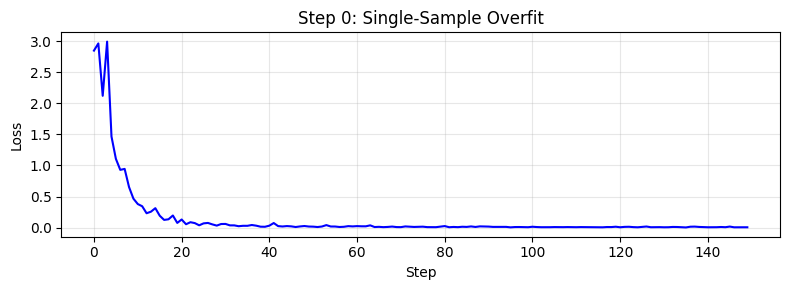

Initial loss: 2.8505  →  Final loss: 0.004567
✅ PASS — Loss collapsed to near-zero. Model can memorize a single sample.
   This means: forward pass, loss, and backward pass are all correct.


In [31]:
# ─────────────────────────────────────────────────────────────
# STEP 0 — Single-sample sanity check
#
# Take ONE image+label. Repeatedly forward-backward until loss
# collapses to near-zero. This verifies:
#   ✓ Model forward pass works
#   ✓ Loss function is correct
#   ✓ Gradients flow (backward pass works)
#   ✓ Optimizer updates weights correctly
#
# If loss doesn't go to ~0 after 100 steps → there is a bug!
# ─────────────────────────────────────────────────────────────
print('='*60)
print('STEP 0: Single-Sample Sanity Check')
print('='*60)

single_img, single_label = images[:2].to(DEVICE), labels[:2].to(DEVICE)

sanity_model = MLP().to(DEVICE)
sanity_opt   = optim.Adam(sanity_model.parameters(), lr=1e-3)
criterion    = nn.CrossEntropyLoss()

losses = []
for step in range(150):
    sanity_model.train()
    sanity_opt.zero_grad()
    out  = sanity_model(single_img)
    loss = criterion(out, single_label)
    loss.backward()
    sanity_opt.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses, 'b-', lw=1.5)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Step 0: Single-Sample Overfit')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Initial loss: {losses[0]:.4f}  →  Final loss: {losses[-1]:.6f}')
if losses[-1] < 0.01:
    print('✅ PASS — Loss collapsed to near-zero. Model can memorize a single sample.')
    print('   This means: forward pass, loss, and backward pass are all correct.')
else:
    print('❌ FAIL — Loss did not collapse. Check model definition and loss function!')

### 🧪 Golden Rule Step 1 — Small Batch Sanity Check (MLP)

STEP 1: Small Batch Overfit (10 samples)


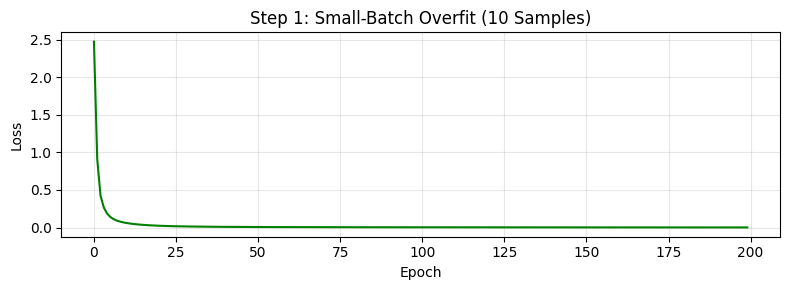

Final train loss: 0.001276 | Train acc: 1.000
✅ PASS — Model achieved near-perfect accuracy on 10 samples.
   Model has sufficient capacity and training works correctly.


In [32]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — Small-batch overfit (10 samples)
#
# If the model can't fit 10 samples, it cannot fit 50,000.
# This catches capacity issues: maybe the model is too small,
# or the learning rate is too low, or there's regularization
# that's too aggressive for this mini experiment.
#
# Expected result: training accuracy → 100%, training loss → ~0
# Validation accuracy doesn't matter here — we're INTENTIONALLY overfitting.
# ─────────────────────────────────────────────────────────────
print('='*60)
print('STEP 1: Small Batch Overfit (10 samples)')
print('='*60)

tiny_imgs,   tiny_labels   = images[:10].to(DEVICE), labels[:10].to(DEVICE)
tiny_dataset = torch.utils.data.TensorDataset(tiny_imgs, tiny_labels)
tiny_loader  = DataLoader(tiny_dataset, batch_size=10)

tiny_model = MLP(dropout=0.0).to(DEVICE)  # NO dropout — we WANT to overfit here
tiny_opt   = optim.Adam(tiny_model.parameters(), lr=1e-3)

tiny_losses = []
for epoch in range(200):
    tiny_model.train()
    for x, y in tiny_loader:
        tiny_opt.zero_grad()
        loss = criterion(tiny_model(x), y)
        loss.backward()
        tiny_opt.step()
    tiny_losses.append(loss.item())

# Final training accuracy
tiny_model.eval()
with torch.no_grad():
    pred = tiny_model(tiny_imgs).argmax(1)
    acc  = (pred == tiny_labels).float().mean().item()

plt.figure(figsize=(8, 3))
plt.plot(tiny_losses, 'g-', lw=1.5)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Step 1: Small-Batch Overfit (10 Samples)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Final train loss: {tiny_losses[-1]:.6f} | Train acc: {acc:.3f}')
if acc >= 0.95:
    print('✅ PASS — Model achieved near-perfect accuracy on 10 samples.')
    print('   Model has sufficient capacity and training works correctly.')
else:
    print('⚠️  WARNING — Could not overfit 10 samples. Model might be too simple or LR too low.')

### 🧪 Golden Rule Step 2 — Baseline MLP (Simple Model, Full Data)

STEP 2: Baseline MLP — Expect Underfitting
Model params: 789,770
  Epoch   1/20 | Train Loss: 1.9301 Acc: 0.322 | Val Loss: 1.7596 Acc: 0.374
  Epoch   5/20 | Train Loss: 1.3041 Acc: 0.559 | Val Loss: 1.7597 Acc: 0.390
  Epoch  10/20 | Train Loss: 0.7988 Acc: 0.758 | Val Loss: 1.8628 Acc: 0.378
  Epoch  15/20 | Train Loss: 0.5032 Acc: 0.861 | Val Loss: 2.0055 Acc: 0.413
  Epoch  20/20 | Train Loss: 0.2970 Acc: 0.928 | Val Loss: 2.2232 Acc: 0.408


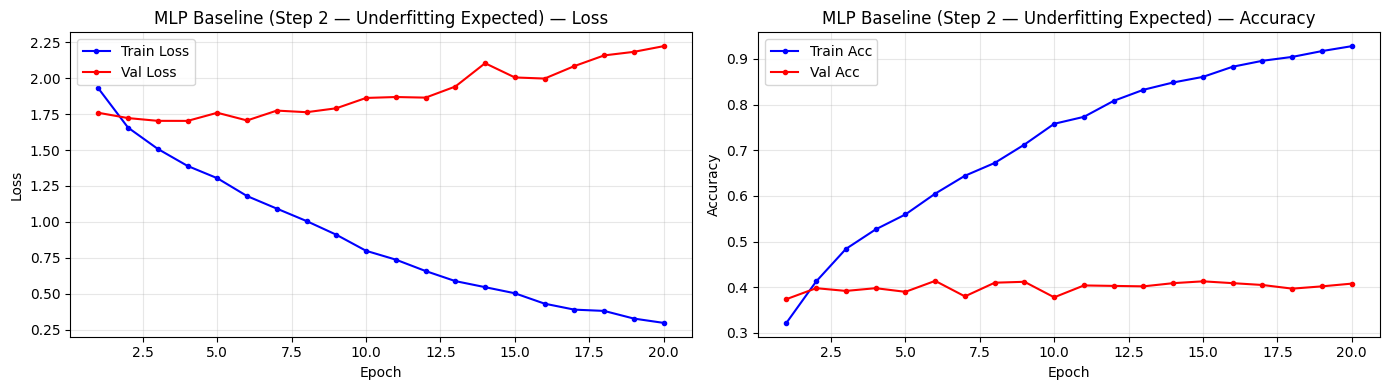


📊 Test Accuracy: 0.4024 (40.2%)

📝 ANALYSIS — Step 2 Results:
   Both train and val accuracy are LOW (underfitting).
   The model has high bias — it's too simple to capture image patterns.
   Flattening the image destroys spatial relationships between pixels.
   A dog's ears are only recognizable in 2D — not in a 1D pixel sequence.
   → SOLUTION: Use CNNs that exploit spatial structure via convolutions.


In [33]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — Baseline: Simple MLP on full (sampled) dataset
#
# We expect: UNDERFITTING.
# The MLP is fundamentally limited — it cannot leverage spatial
# structure in images. Flattening destroys relative positions
# of pixels. A 'cat ear' is just a sequence of numbers, not
# a 2D pattern. The model will plateau at a mediocre accuracy.
#
# This gives us the BASELINE to beat with CNNs.
# ─────────────────────────────────────────────────────────────
print('='*60)
print('STEP 2: Baseline MLP — Expect Underfitting')
print('='*60)

mlp_baseline = MLP(hidden_dims=[256], dropout=0.0).to(DEVICE)  # Intentionally small
criterion    = nn.CrossEntropyLoss(label_smoothing=0.0)         # Plain CE for baseline
optimizer    = optim.SGD(mlp_baseline.parameters(), lr=0.01, momentum=0.9)

print(f'Model params: {count_params(mlp_baseline):,}')
hist_mlp_baseline = train_model(
    mlp_baseline, train_loader, val_loader,
    optimizer, criterion,
    num_epochs=20,
    experiment_name='mlp_baseline'
)
plot_history(hist_mlp_baseline, 'MLP Baseline (Step 2 — Underfitting Expected)')

_, test_acc = evaluate(mlp_baseline, test_loader, criterion)
print(f'\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print('')
print('📝 ANALYSIS — Step 2 Results:')
print('   Both train and val accuracy are LOW (underfitting).')
print('   The model has high bias — it\'s too simple to capture image patterns.')
print('   Flattening the image destroys spatial relationships between pixels.')
print('   A dog\'s ears are only recognizable in 2D — not in a 1D pixel sequence.')
print('   → SOLUTION: Use CNNs that exploit spatial structure via convolutions.')

### 🧪 Golden Rule Step 3 — Complex MLP (Reduce Bias)

STEP 3: Large MLP — Reduce Bias, Expect Overfitting
Model params: 3,809,034
  Epoch   1/20 | Train Loss: 1.9141 Acc: 0.315 | Val Loss: 1.7697 Acc: 0.353
  Epoch   5/20 | Train Loss: 1.1885 Acc: 0.584 | Val Loss: 1.8766 Acc: 0.381
  Epoch  10/20 | Train Loss: 0.5791 Acc: 0.804 | Val Loss: 2.0832 Acc: 0.396
  Epoch  15/20 | Train Loss: 0.2675 Acc: 0.912 | Val Loss: 2.5642 Acc: 0.395
  Epoch  20/20 | Train Loss: 0.1755 Acc: 0.945 | Val Loss: 2.8389 Acc: 0.418


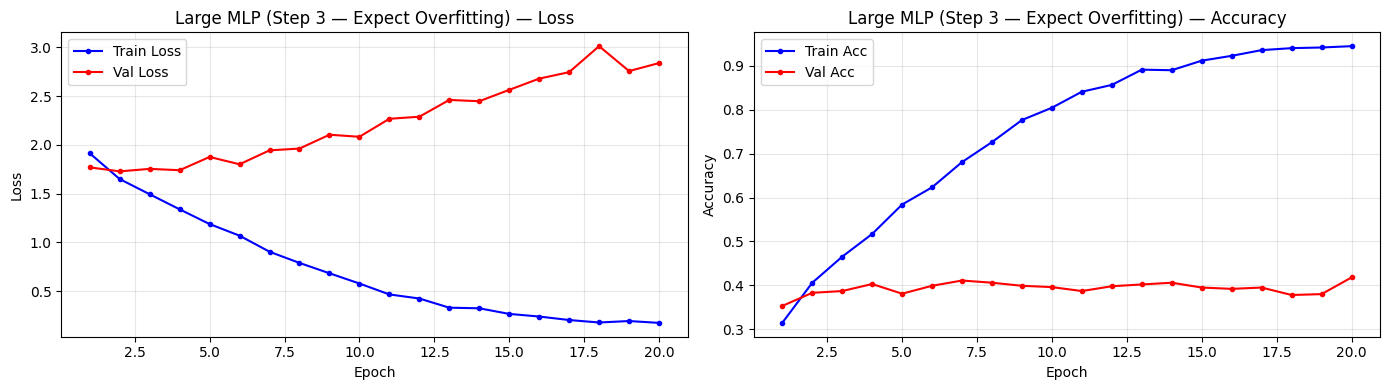


📊 Test Accuracy: 0.3795 (38.0%)

📝 ANALYSIS — Step 3 Results:
   Train accuracy > Val accuracy → clear overfitting (high variance).
   The model memorized training pixels but can't generalize.
   More capacity helped training loss, but widened the generalization gap.
   → SOLUTION for MLP: add regularization (Step 4)
   → BETTER SOLUTION: switch to CNN (Part 2) — inductive bias is the real fix.


In [34]:
# ─────────────────────────────────────────────────────────────
# STEP 3 — Bigger MLP to reduce bias
#
# Increase capacity: more layers, more neurons.
# Expected: train accuracy improves significantly,
# but validation accuracy trails behind → OVERFITTING.
# The gap between train and val is the variance problem.
# MLP overfits pixel-level memorization without generalizing.
# ─────────────────────────────────────────────────────────────
print('='*60)
print('STEP 3: Large MLP — Reduce Bias, Expect Overfitting')
print('='*60)

mlp_large = MLP(hidden_dims=[1024, 512, 256], dropout=0.0).to(DEVICE)
optimizer = optim.Adam(mlp_large.parameters(), lr=1e-3)

print(f'Model params: {count_params(mlp_large):,}')
hist_mlp_large = train_model(
    mlp_large, train_loader, val_loader,
    optimizer, criterion,
    num_epochs=20,
    experiment_name='mlp_large'
)
plot_history(hist_mlp_large, 'Large MLP (Step 3 — Expect Overfitting)')

_, test_acc = evaluate(mlp_large, test_loader, criterion)
print(f'\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print('')
print('📝 ANALYSIS — Step 3 Results:')
print('   Train accuracy > Val accuracy → clear overfitting (high variance).')
print('   The model memorized training pixels but can\'t generalize.')
print('   More capacity helped training loss, but widened the generalization gap.')
print('   → SOLUTION for MLP: add regularization (Step 4)')
print('   → BETTER SOLUTION: switch to CNN (Part 2) — inductive bias is the real fix.')

### 🧪 Golden Rule Step 4 — Regularized MLP (Reduce Variance)

STEP 4: Regularized MLP — Reduce Variance
Model params: 3,809,034
  Epoch   1/20 | Train Loss: 2.1797 Acc: 0.218 | Val Loss: 1.9567 Acc: 0.317
  Epoch   5/20 | Train Loss: 1.8081 Acc: 0.403 | Val Loss: 1.7913 Acc: 0.419
  Epoch  10/20 | Train Loss: 1.5910 Acc: 0.503 | Val Loss: 1.7557 Acc: 0.433
  Epoch  15/20 | Train Loss: 1.3824 Acc: 0.606 | Val Loss: 1.7372 Acc: 0.458
  Epoch  20/20 | Train Loss: 1.2716 Acc: 0.665 | Val Loss: 1.7402 Acc: 0.455


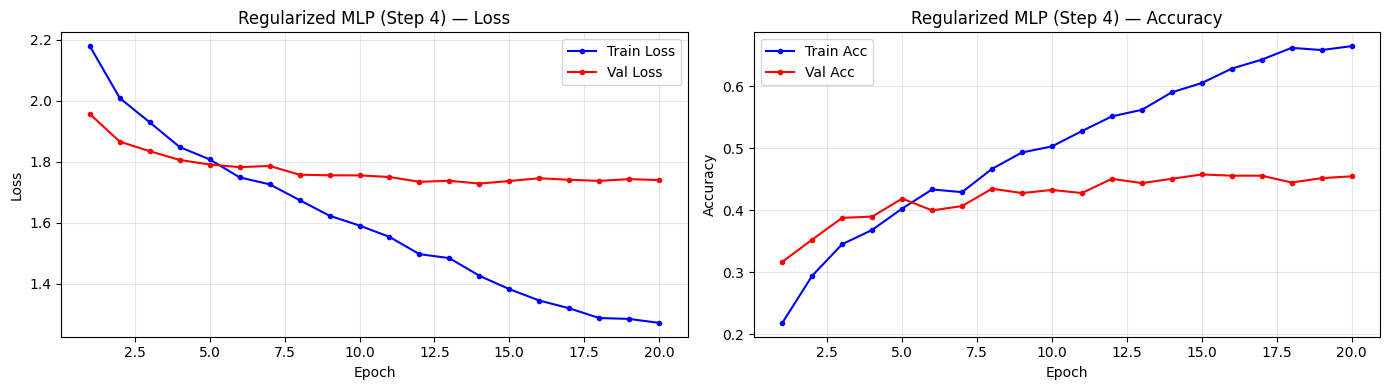


📊 Test Accuracy: 0.4537 (45.4%)

📝 ANALYSIS — Step 4 Results:
   Train-val gap is smaller → regularization worked to reduce variance.
   But the absolute accuracy is still limited by the MLP's inductive bias.
   FUNDAMENTAL CONCLUSION: No amount of regularization fixes a wrong architecture.
   MLPs are simply not designed for images. Time for CNNs.


In [35]:
# ─────────────────────────────────────────────────────────────
# STEP 4 — Regularized MLP
#
# Techniques applied:
#   1. Dropout (0.5) — randomly silence neurons during training,
#      preventing co-adaptation and forcing redundant representations
#   2. Weight decay (L2) — penalizes large weights via optimizer,
#      shrinks model towards simpler solutions
#   3. Label smoothing — soft targets (0.9/0.1 instead of 1/0)
#      prevent the model from becoming overconfident
#
# Expected: train-val gap shrinks, val accuracy improves.
# Note: even with regularization, MLP performance plateaus well
# below CNN — regularization cannot compensate for wrong inductive bias.
# ─────────────────────────────────────────────────────────────
print('='*60)
print('STEP 4: Regularized MLP — Reduce Variance')
print('='*60)

mlp_reg   = MLP(hidden_dims=[1024, 512, 256], dropout=0.5).to(DEVICE)
optimizer = optim.Adam(mlp_reg.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f'Model params: {count_params(mlp_reg):,}')
hist_mlp_reg = train_model(
    mlp_reg, train_loader, val_loader,
    optimizer, criterion_smooth,
    num_epochs=20, scheduler=scheduler,
    experiment_name='mlp_regularized'
)
plot_history(hist_mlp_reg, 'Regularized MLP (Step 4)')

_, test_acc = evaluate(mlp_reg, test_loader, criterion)
print(f'\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print('')
print('📝 ANALYSIS — Step 4 Results:')
print('   Train-val gap is smaller → regularization worked to reduce variance.')
print('   But the absolute accuracy is still limited by the MLP\'s inductive bias.')
print('   FUNDAMENTAL CONCLUSION: No amount of regularization fixes a wrong architecture.')
print('   MLPs are simply not designed for images. Time for CNNs.')

---
# PART 2 — CNN (Convolutional Neural Network)

> **Why CNNs?** Convolutions exploit three key properties of images:
> 1. **Local connectivity** — a filter only looks at a small region (e.g., 3×3), matching how visual features are local
> 2. **Parameter sharing** — the same filter is applied everywhere (translation equivariance)
> 3. **Hierarchical features** — early layers detect edges, middle layers detect textures, deep layers detect objects
>
> This inductive bias is perfectly aligned with how images work. A CNN with far fewer parameters than an MLP will dramatically outperform it.

In [36]:
# ─────────────────────────────────────────────────────────────
# CNN Architecture — VGG-style with progressive depth
#
# Architecture:
#   Block 1: Conv 3×3 (3→32)   → BN → ReLU → Conv (32→32)  → BN → ReLU → MaxPool 2×2
#   Block 2: Conv 3×3 (32→64)  → BN → ReLU → Conv (64→64)  → BN → ReLU → MaxPool 2×2
#   Block 3: Conv 3×3 (64→128) → BN → ReLU → Conv (128→128)→ BN → ReLU → MaxPool 2×2
#   Classifier: AdaptiveAvgPool → FC(128→256) → ReLU → Dropout → FC(256→10)
#
# Design choices explained:
#   - Batch Norm: normalizes feature maps, stabilizes training, acts as regularizer
#   - MaxPool: reduces spatial dimensions, builds translation invariance
#   - Double conv blocks (VGG style): two 3×3 convs ≈ one 5×5 but with fewer params
#   - AdaptiveAvgPool: makes the network input-size agnostic
#   - padding=1 on convs: preserves spatial dimensions within each block
# ─────────────────────────────────────────────────────────────

class ConvBlock(nn.Module):
    """Two convolutional layers with BN+ReLU, followed by MaxPool."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # Halve spatial dimensions: 32→16→8→4
        )
    def forward(self, x):
        return self.block(x)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        # Feature extractor — the spatial hierarchy
        self.features = nn.Sequential(
            ConvBlock(3,   32),    # 32×32 → 16×16, 32 feature maps
            ConvBlock(32,  64),    # 16×16 →  8×8,  64 feature maps
            ConvBlock(64, 128),    #  8×8  →  4×4, 128 feature maps
        )
        # Global average pooling collapses spatial dims to 1×1
        # This is better than flattening for generalization (less overfitting)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)          # Extract spatial features
        x = self.pool(x).flatten(1)   # Global avg pool + flatten
        return self.classifier(x)

    def get_feature_maps(self, x):
        """Return intermediate feature maps for visualization (used later)."""
        maps = {}
        for i, block in enumerate(self.features):
            x = block(x)
            maps[f'block_{i+1}'] = x.detach().cpu()
        return maps


cnn_test = SimpleCNN().to(DEVICE)
print(f'CNN parameters: {count_params(cnn_test):,}')
print(f'(Compare: MLP had {count_params(mlp_large):,} params — CNN uses spatial structure more efficiently)')
print(cnn_test)

CNN parameters: 323,050
(Compare: MLP had 3,809,034 params — CNN uses spatial structure more efficiently)
SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): C

### 🔍 CNN Filter Visualization — BEFORE Training

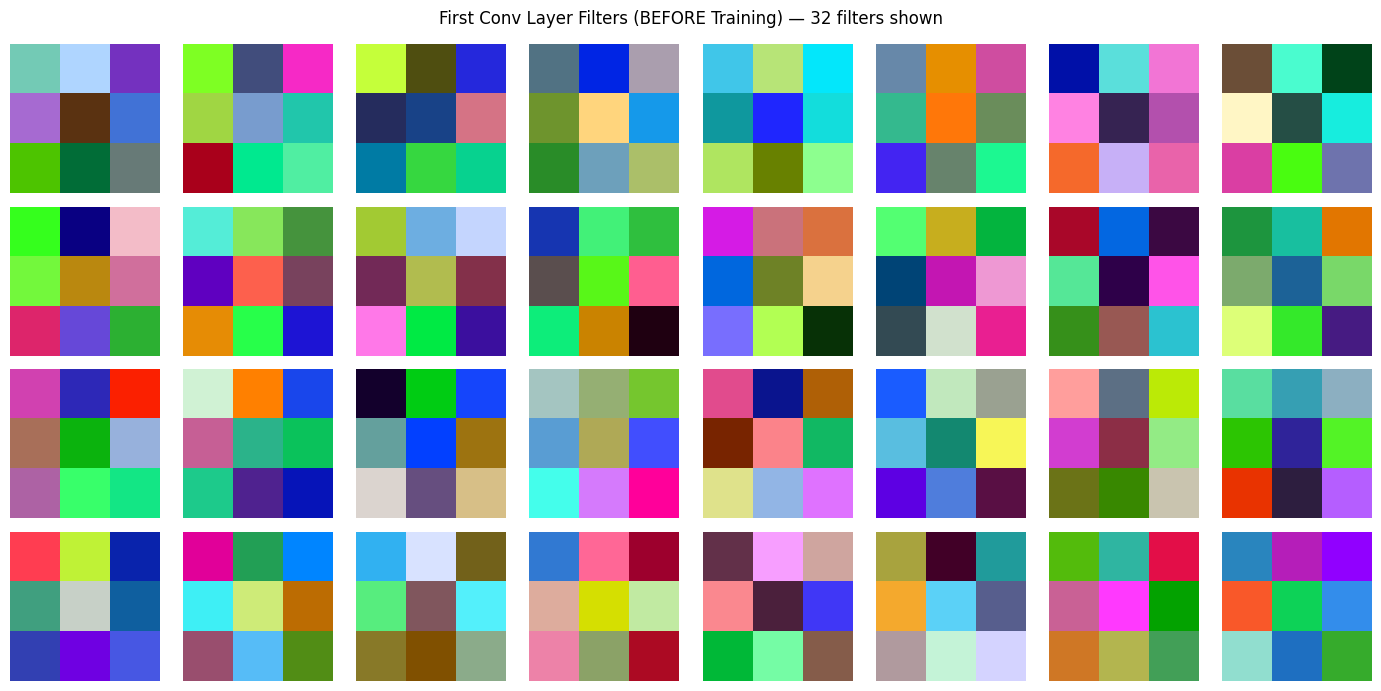

📝 Observation: Random noise filters — no structure, no meaning.
   After training, these should become structured feature detectors.


In [37]:
# ─────────────────────────────────────────────────────────────
# Visualize first-layer filters BEFORE training
#
# Before training, filters are randomly initialized (Kaiming uniform by default).
# They look like random noise — no structure whatsoever.
# After training, they should develop into edge detectors, color detectors,
# frequency selectors, etc. — the hallmarks of visual feature learning.
#
# We look at the FIRST conv layer because:
#   1. It operates on actual RGB pixels — we can interpret it visually
#   2. Deeper layer filters operate on abstract feature maps (harder to interpret)
# ─────────────────────────────────────────────────────────────

def visualize_filters(model, layer_name='First Conv Layer', title_suffix=''):
    """Visualize filters of the first convolutional layer."""
    # Get weights of the very first Conv2d
    first_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            first_conv = module
            break

    weights = first_conv.weight.data.cpu().clone()
    # Normalize each filter to [0,1] for display
    n_filters = min(32, weights.shape[0])
    weights = weights[:n_filters]

    fig, axes = plt.subplots(4, 8, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        if i < n_filters:
            filt = weights[i].permute(1, 2, 0)  # (C,H,W) → (H,W,C)
            # Normalize to [0,1] for imshow
            filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
            ax.imshow(filt.numpy())
        ax.axis('off')
    plt.suptitle(f'{layer_name} Filters ({title_suffix}) — {n_filters} filters shown', fontsize=12)
    plt.tight_layout()
    plt.show()


untrained_cnn = SimpleCNN().to(DEVICE)
visualize_filters(untrained_cnn, title_suffix='BEFORE Training')
print('📝 Observation: Random noise filters — no structure, no meaning.')
print('   After training, these should become structured feature detectors.')

In [53]:
## <HUMAN WRITTEN COMMENTS>     
## The 3x3 filter initially look like total meaningless randomness

### 🧪 Golden Rule Steps 0-4 for CNN

In [38]:
# ─────────────────────────────────────────────────────────────
# CNN Step 0+1 — Quick sanity checks (combined for brevity)
# ─────────────────────────────────────────────────────────────
print('='*60)
print('CNN Steps 0+1: Sanity Checks')
print('='*60)

# Single sample
cnn_sanity = SimpleCNN(dropout=0.0).to(DEVICE)
opt_s = optim.Adam(cnn_sanity.parameters(), lr=1e-3)
s_img, s_lbl = images[:1].to(DEVICE), labels[:1].to(DEVICE)
losses_s = []
for _ in range(100):
    cnn_sanity.train(); opt_s.zero_grad()
    l = criterion(cnn_sanity(s_img), s_lbl); l.backward(); opt_s.step()
    losses_s.append(l.item())

print(f'Step 0 — Single sample loss: {losses_s[0]:.4f} → {losses_s[-1]:.6f}',
      '✅' if losses_s[-1] < 0.01 else '❌')

# Small batch
cnn_tiny = SimpleCNN(dropout=0.0).to(DEVICE)
opt_t = optim.Adam(cnn_tiny.parameters(), lr=1e-3)
t_imgs, t_lbls = images[:10].to(DEVICE), labels[:10].to(DEVICE)
for _ in range(300):
    cnn_tiny.train(); opt_t.zero_grad()
    l = criterion(cnn_tiny(t_imgs), t_lbls); l.backward(); opt_t.step()
cnn_tiny.eval()
with torch.no_grad():
    tiny_acc = (cnn_tiny(t_imgs).argmax(1) == t_lbls).float().mean().item()
print(f'Step 1 — Small batch acc: {tiny_acc:.3f}', '✅' if tiny_acc >= 0.95 else '⚠️')

CNN Steps 0+1: Sanity Checks
Step 0 — Single sample loss: 2.2737 → 0.000005 ✅
Step 1 — Small batch acc: 1.000 ✅


CNN Step 2: Baseline CNN — Expect Underfitting
Model params: 5,418
  Epoch   1/20 | Train Loss: 2.2904 Acc: 0.146 | Val Loss: 2.2505 Acc: 0.183
  Epoch   5/20 | Train Loss: 1.9899 Acc: 0.260 | Val Loss: 1.9626 Acc: 0.273
  Epoch  10/20 | Train Loss: 1.7901 Acc: 0.326 | Val Loss: 1.7514 Acc: 0.339
  Epoch  15/20 | Train Loss: 1.7015 Acc: 0.377 | Val Loss: 1.6686 Acc: 0.360
  Epoch  20/20 | Train Loss: 1.6294 Acc: 0.401 | Val Loss: 1.6104 Acc: 0.422


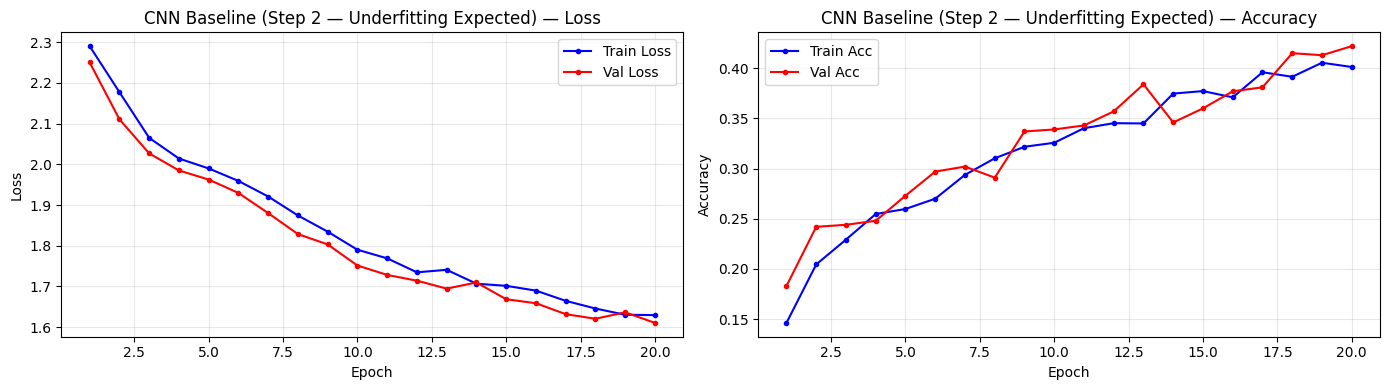


📊 Test Accuracy: 0.4138
📝 Already beating MLP! CNNs win even when smaller, because spatial inductive bias matters.


In [39]:
# ─────────────────────────────────────────────────────────────
# CNN Step 2 — Baseline CNN (no regularization, small)
#
# Using only Block 1 (small model) without augmentation.
# Expected: underfits — accuracy plateaus at a moderate level
# because the model doesn't have enough capacity for CIFAR-10's complexity.
# ─────────────────────────────────────────────────────────────
print('='*60)
print('CNN Step 2: Baseline CNN — Expect Underfitting')
print('='*60)

class TinyCNN(nn.Module):
    """Deliberately too-small CNN for the baseline step."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(32, 10)
    def forward(self, x):
        return self.fc(self.net(x).flatten(1))

cnn_baseline = TinyCNN().to(DEVICE)
print(f'Model params: {count_params(cnn_baseline):,}')
optimizer = optim.SGD(cnn_baseline.parameters(), lr=0.01, momentum=0.9)

hist_cnn_base = train_model(
    cnn_baseline, train_loader, val_loader,
    optimizer, criterion,
    num_epochs=20,
    experiment_name='cnn_baseline'
)
plot_history(hist_cnn_base, 'CNN Baseline (Step 2 — Underfitting Expected)')
_, ta = evaluate(cnn_baseline, test_loader, criterion)
print(f'\n📊 Test Accuracy: {ta:.4f}')
print('📝 Already beating MLP! CNNs win even when smaller, because spatial inductive bias matters.')

CNN Step 3: Full CNN — Reduce Bias, Expect Overfitting
Model params: 323,050
  Epoch   1/25 | Train Loss: 1.8089 Acc: 0.310 | Val Loss: 1.7088 Acc: 0.325
  Epoch   5/25 | Train Loss: 1.1123 Acc: 0.600 | Val Loss: 1.4394 Acc: 0.506
  Epoch  10/25 | Train Loss: 0.7099 Acc: 0.744 | Val Loss: 1.4381 Acc: 0.553
  Epoch  15/25 | Train Loss: 0.2728 Acc: 0.910 | Val Loss: 2.1326 Acc: 0.496
  Epoch  20/25 | Train Loss: 0.1038 Acc: 0.967 | Val Loss: 1.7235 Acc: 0.611
  Epoch  25/25 | Train Loss: 0.1143 Acc: 0.965 | Val Loss: 1.8867 Acc: 0.608


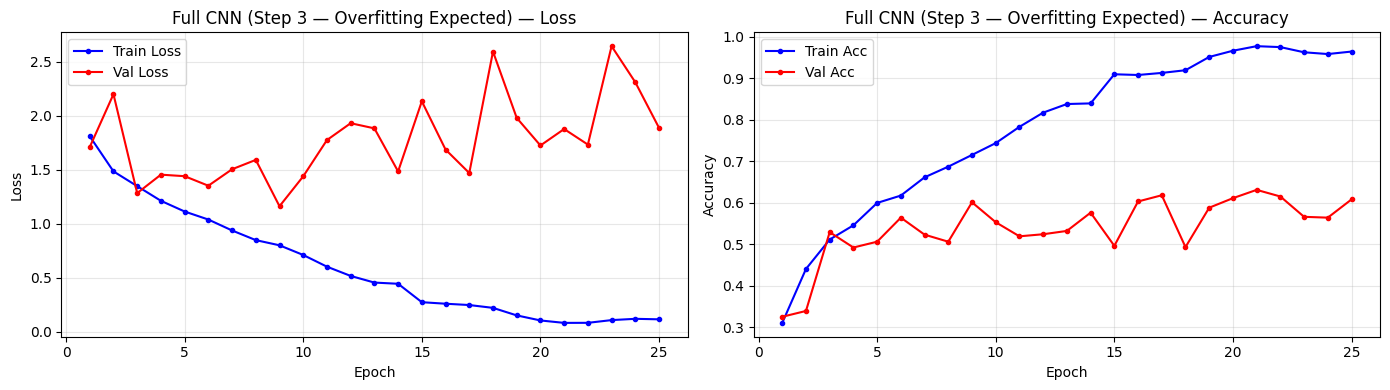


📊 Test Accuracy: 0.5741
📝 High train acc + lower val acc = overfitting. Model learned the noise in training data.
   This is EXPECTED and DESIRED at this step — it proves we have enough capacity.


In [40]:
# ─────────────────────────────────────────────────────────────
# CNN Step 3 — Full CNN (Reduce Bias)
#
# Now use the full 3-block architecture with 128 channels.
# No regularization — we WANT to see overfitting here to
# confirm the model has sufficient capacity for CIFAR-10.
# Expected: train accuracy >> val accuracy (overfitting).
# ─────────────────────────────────────────────────────────────
print('='*60)
print('CNN Step 3: Full CNN — Reduce Bias, Expect Overfitting')
print('='*60)

cnn_full = SimpleCNN(dropout=0.0).to(DEVICE)   # No regularization intentionally
print(f'Model params: {count_params(cnn_full):,}')
optimizer = optim.Adam(cnn_full.parameters(), lr=1e-3)

hist_cnn_full = train_model(
    cnn_full, train_loader, val_loader,
    optimizer, criterion,
    num_epochs=25,
    experiment_name='cnn_overfit'
)
plot_history(hist_cnn_full, 'Full CNN (Step 3 — Overfitting Expected)')
_, ta = evaluate(cnn_full, test_loader, criterion)
print(f'\n📊 Test Accuracy: {ta:.4f}')
print('📝 High train acc + lower val acc = overfitting. Model learned the noise in training data.')
print('   This is EXPECTED and DESIRED at this step — it proves we have enough capacity.')

CNN Step 4: Regularized CNN — Reduce Variance
Model params: 323,050
  Epoch   1/30 | Train Loss: 2.0511 Acc: 0.232 | Val Loss: 1.9157 Acc: 0.299
  Epoch   5/30 | Train Loss: 1.6486 Acc: 0.459 | Val Loss: 1.6570 Acc: 0.452
  Epoch  10/30 | Train Loss: 1.4232 Acc: 0.585 | Val Loss: 1.7821 Acc: 0.472
  Epoch  15/30 | Train Loss: 1.2527 Acc: 0.666 | Val Loss: 1.3802 Acc: 0.593
  Epoch  20/30 | Train Loss: 1.1144 Acc: 0.740 | Val Loss: 1.2767 Acc: 0.642
  Epoch  25/30 | Train Loss: 1.0383 Acc: 0.783 | Val Loss: 1.2332 Acc: 0.666
  Epoch  30/30 | Train Loss: 1.0022 Acc: 0.799 | Val Loss: 1.2263 Acc: 0.663


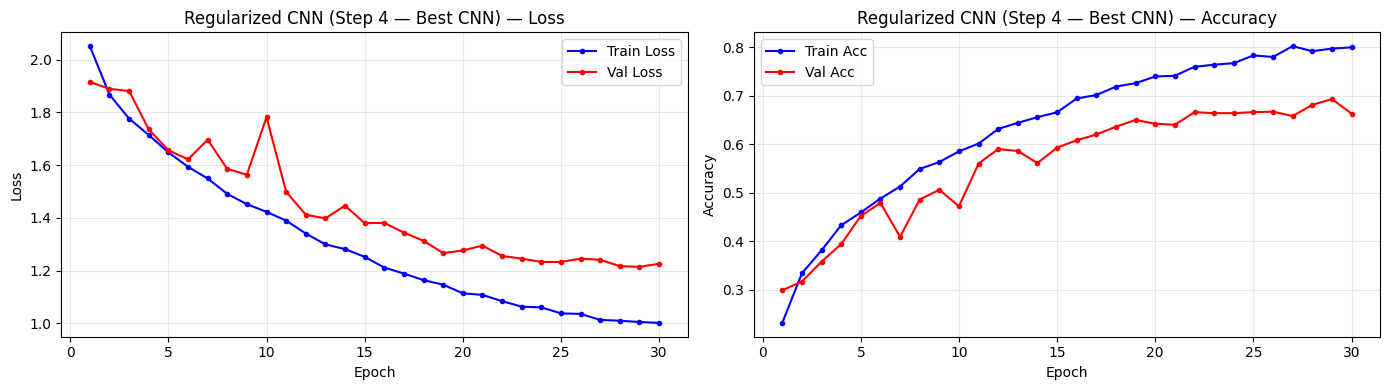


📊 Test Accuracy: 0.7057 (70.6%)
📝 Much smaller train-val gap → regularization is working!
   Augmentation taught the model to be position/orientation invariant.
   This is our best custom CNN — we'll now compare against transfer learning.


In [41]:
# ─────────────────────────────────────────────────────────────
# CNN Step 4 — Regularized CNN (Reduce Variance)
#
# Regularization strategy:
#   1. Data augmentation (random crop + flip + color jitter)
#      → most powerful regularizer for images
#   2. Dropout (0.5) in classifier head
#   3. Weight decay (L2 regularization) in optimizer
#   4. Cosine annealing LR schedule
#      → starts high (fast learning) → ends low (fine-grained refinement)
#   5. Label smoothing
#      → prevents overconfident predictions
#
# Expected: train-val gap closes, val accuracy improves notably.
# ─────────────────────────────────────────────────────────────
print('='*60)
print('CNN Step 4: Regularized CNN — Reduce Variance')
print('='*60)

cnn_reg = SimpleCNN(dropout=0.5).to(DEVICE)
print(f'Model params: {count_params(cnn_reg):,}')
optimizer = optim.AdamW(cnn_reg.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)

# KEY: use augmented loader for training (extra regularization via data diversity)
hist_cnn_reg = train_model(
    cnn_reg, aug_train_loader, aug_val_loader,
    optimizer, criterion_smooth,
    num_epochs=30, scheduler=scheduler,
    experiment_name='cnn_regularized'
)
plot_history(hist_cnn_reg, 'Regularized CNN (Step 4 — Best CNN)')

_, ta = evaluate(cnn_reg, test_loader, criterion)
print(f'\n📊 Test Accuracy: {ta:.4f} ({ta*100:.1f}%)')
print('📝 Much smaller train-val gap → regularization is working!')
print('   Augmentation taught the model to be position/orientation invariant.')
print('   This is our best custom CNN — we\'ll now compare against transfer learning.')

### 🔍 CNN Filter Visualization — AFTER Training

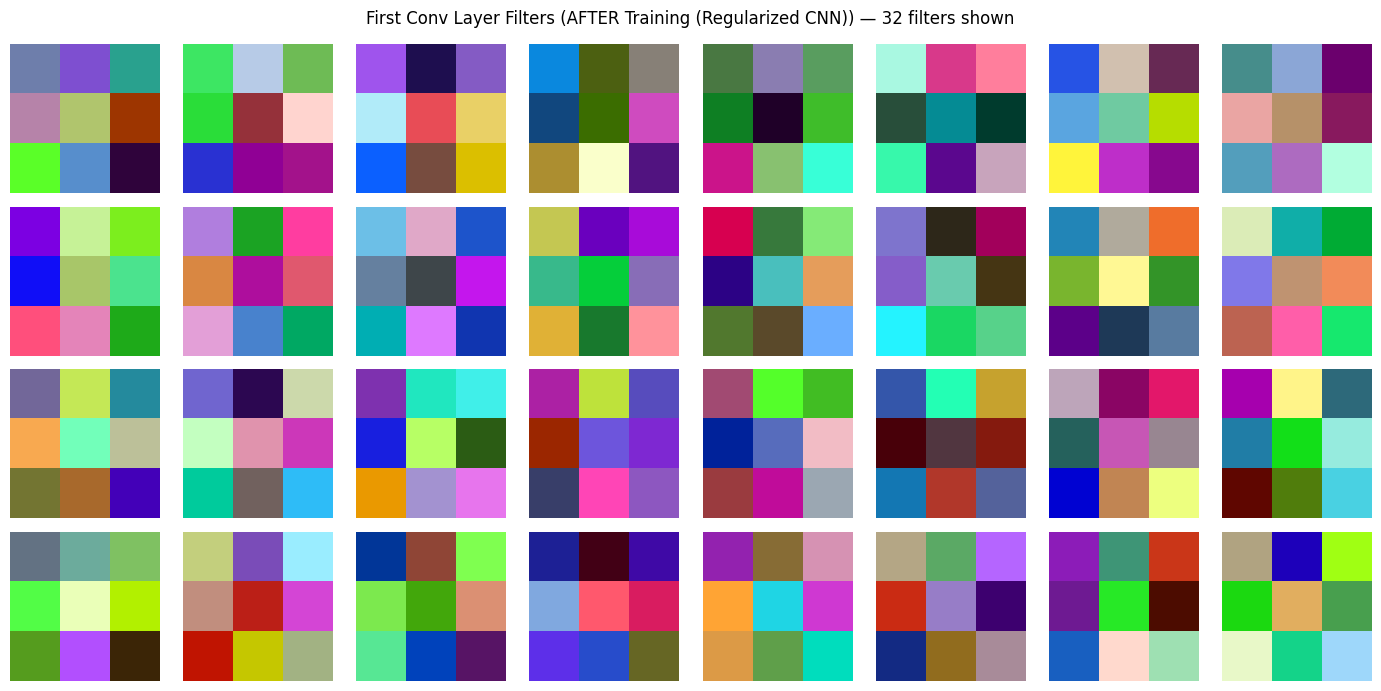

📝 Compare with BEFORE training:
   Random noise → Structured patterns!
   You should see: edge detectors, color detectors, Gabor filters.
   These emergent features are exactly what the model learned to care about.


In [42]:
# ─────────────────────────────────────────────────────────────
# Visualize filters AFTER training
#
# Well-trained first-layer filters should show:
#   - Edge detectors (horizontal, vertical, diagonal edges)
#   - Color detectors (red/green/blue sensitive filters)
#   - Gabor-like patterns (oriented frequency filters)
#   - Blob detectors (center-surround)
#
# These patterns emerge because they are genuinely useful
# for recognizing the CIFAR-10 classes. The network discovered
# them through gradient descent alone — no human prior.
# ─────────────────────────────────────────────────────────────
visualize_filters(cnn_reg, title_suffix='AFTER Training (Regularized CNN)')
print('📝 Compare with BEFORE training:')
print('   Random noise → Structured patterns!')
print('   You should see: edge detectors, color detectors, Gabor filters.')
print('   These emergent features are exactly what the model learned to care about.')

In [55]:
## <HUMAN WRITTEN COMMENTS>     
## the post-training kernels can't really be interpreted to something that a human can understand [especially since they are 3x3 kernels]
## but this is normal since the model is optimizing these kernels values to produce something that's understandable 
## by the computer, especially since it's operating on a huge amounts of data with a huge variations and patterns
## so  the kernel may not be meaningful to us, but for a neural network, it is indeed meaningful.
## Unless that it's something obvious like say "sobel" or "canny" or prewitt filters, we can't really understand what these 3x3 filters indicate

### 🗺️ Feature Map Visualization

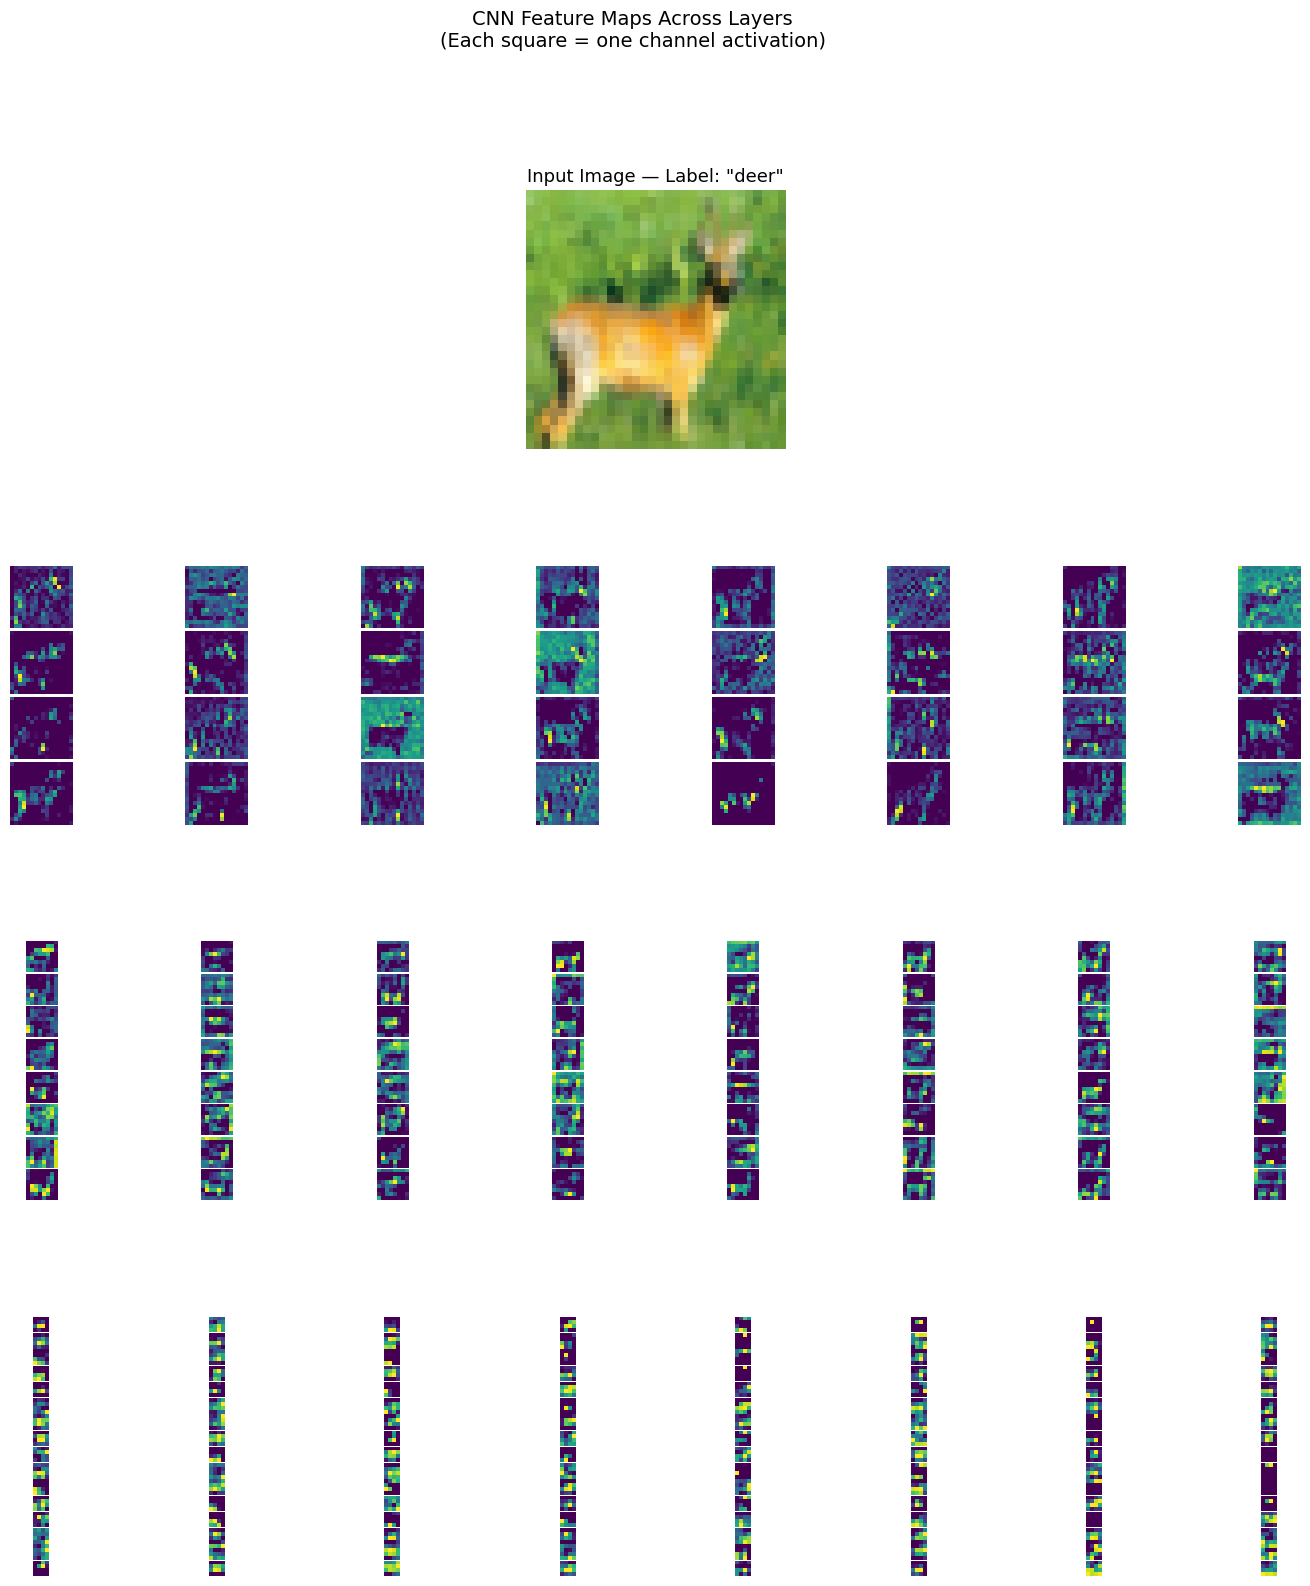

📝 Feature map observations:
   Block 1 (16×16): Edges and large structures.
   Block 2 (8×8):   Textures and mid-level patterns.
   Block 3 (4×4):   Highly abstract semantic activations.
   Note: resolution decreases while channel count increases.


In [43]:
# ─────────────────────────────────────────────────────────────
# Feature map visualization across CNN layers
# ─────────────────────────────────────────────────────────────

cnn_reg.eval()

# Pick a sample image
sample_img, sample_lbl = images[5:6].to(DEVICE), labels[5]
feature_maps = cnn_reg.get_feature_maps(sample_img)

# Original image
orig_display = denormalize(images[5]).permute(1,2,0).numpy()

fig = plt.figure(figsize=(18, 18))
gs = gridspec.GridSpec(4, 1, hspace=0.45)

# ─────────────────────────────────────────
# Row 0 — Original Image
# ─────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.imshow(orig_display)
ax0.set_title(f'Input Image — Label: "{CLASS_NAMES[sample_lbl]}"', fontsize=13)
ax0.axis('off')

block_info = [
    ('block_1', 32, '32 channels, 16×16 — Low-level edges & colors'),
    ('block_2', 64, '64 channels, 8×8 — Mid-level textures & shapes'),
    ('block_3', 128, '128 channels, 4×4 — High-level semantic features'),
]

for row_idx, (block_key, n_show, desc) in enumerate(block_info, start=1):

    fmap = feature_maps[block_key][0]
    n_show = min(n_show, fmap.shape[0])

    n_cols = 8
    n_rows = int(np.ceil(n_show / n_cols))

    inner_gs = gridspec.GridSpecFromSubplotSpec(
        n_rows,
        n_cols,
        subplot_spec=gs[row_idx],
        wspace=0.05,
        hspace=0.05
    )

    axes = []

    for i in range(n_show):

        r = i // n_cols
        c = i % n_cols

        ax = fig.add_subplot(inner_gs[r, c])
        axes.append(ax)

        ch_map = fmap[i].detach().cpu().numpy()

        ax.imshow(ch_map, cmap='viridis')
        ax.axis('off')

    # Hide unused grid cells
    for i in range(n_show, n_rows * n_cols):
        r = i // n_cols
        c = i % n_cols
        ax = fig.add_subplot(inner_gs[r, c])
        ax.axis('off')

    # Attach block label to the first feature map axis
    axes[0].set_ylabel(
        f'{block_key.upper()}\n{desc}',
        fontsize=9,
        rotation=0,
        labelpad=120,
        va='center'
    )

plt.suptitle(
    'CNN Feature Maps Across Layers\n'
    "(Each square = one channel activation)",
    fontsize=14
)

plt.show()

print('📝 Feature map observations:')
print('   Block 1 (16×16): Edges and large structures.')
print('   Block 2 (8×8):   Textures and mid-level patterns.')
print('   Block 3 (4×4):   Highly abstract semantic activations.')
print('   Note: resolution decreases while channel count increases.')

In [57]:
## <HUMAN WRITTEN COMMENTS>     
## the resolution of CIFAR-100 is kinda small
## but we can still see that the each feature map seems to focus on / highlight some parts of the input image

---
# PART 3 — Transfer Learning with ResNet-34

> **Transfer Learning Philosophy**: ResNet-34, trained on ImageNet's 1.28M images across 1000 classes, has already learned an extraordinary hierarchy of visual features — from Gabor filters in layer 1 to complex object parts in layer 4. Instead of learning from scratch with our small CIFAR-10 sample, we **reuse** these features.
>
> We test three scenarios along the "freeze/finetune" spectrum:
> - **3-A** FC Only: Freeze everything, only train the new classification head
> - **3-B** Partial Finetune: Unfreeze the last residual blocks (high-level feature tuning)
> - **3-C** Full Finetune: Unfreeze all parameters (maximum adaptation)
>
> **Key consideration**: As we unfreeze more layers, we must use a LOWER learning rate to avoid destroying pretrained features.

In [44]:
# ─────────────────────────────────────────────────────────────
# Load pretrained ResNet-34
#
# WEIGHTS=DEFAULT loads ImageNet-1k pretrained weights.
# These weights represent ~weeks of GPU training on 1.28M images.
# We get all of that for free!
#
# Critical modification: replace the final FC layer
#   Original: nn.Linear(512, 1000) → 1000 ImageNet classes
#   Ours:     nn.Linear(512, 10)   → 10 CIFAR-10 classes
# ─────────────────────────────────────────────────────────────

def build_resnet34(num_classes=10):
    """Load pretrained ResNet-34 and replace the classification head."""
    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
    # Replace the final fully-connected layer
    in_features = model.fc.in_features  # 512 for ResNet-34
    model.fc = nn.Sequential(
        nn.Dropout(0.3),                  # Light dropout before FC for regularization
        nn.Linear(in_features, num_classes)
    )
    return model


def freeze_all_except_fc(model):
    """Freeze all layers except the final FC. Used for scenario 3-A."""
    for name, param in model.named_parameters():
        param.requires_grad = 'fc' in name  # Only FC layers are trainable
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'   Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.1f}%)')


def freeze_except_last_blocks(model, n_blocks=2):
    """Freeze early layers, unfreeze last n residual blocks + FC. Used for 3-B."""
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False
    # Unfreeze last n ResNet layer groups + FC
    layers_to_unfreeze = [model.fc]
    resnet_layers = [model.layer4, model.layer3]  # Layer4=deepest, Layer3=second deepest
    for i in range(min(n_blocks, len(resnet_layers))):
        layers_to_unfreeze.append(resnet_layers[i])
    for layer in layers_to_unfreeze:
        for param in layer.parameters():
            param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'   Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.1f}%)')


def unfreeze_all(model):
    """Unfreeze all parameters for full finetuning. Used for 3-C."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters())
    print(f'   Trainable: {trainable:,} / {trainable:,} params (100%)')


print('✅ ResNet-34 utilities ready.')

✅ ResNet-34 utilities ready.


SCENARIO 3-A: FC Head Only
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 191MB/s] 


   Trainable: 5,130 / 21,289,802 params (0.0%)
  Epoch   1/15 | Train Loss: 1.7964 Acc: 0.432 | Val Loss: 1.3663 Acc: 0.659
  Epoch   5/15 | Train Loss: 1.2194 Acc: 0.704 | Val Loss: 1.1031 Acc: 0.755
  Epoch  10/15 | Train Loss: 1.1685 Acc: 0.724 | Val Loss: 1.0745 Acc: 0.785
  Epoch  15/15 | Train Loss: 1.1513 Acc: 0.732 | Val Loss: 1.0665 Acc: 0.768


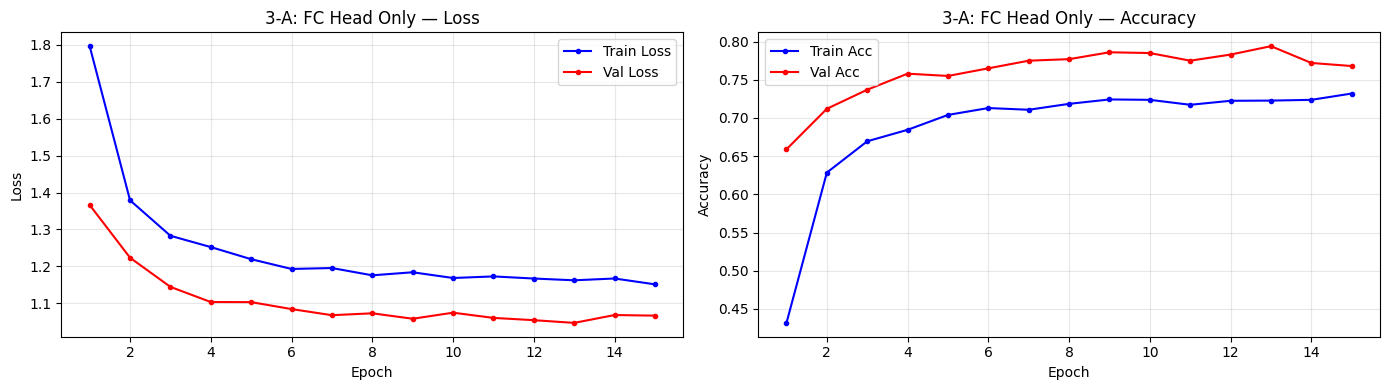


📊 Test Accuracy: 0.7835 (78.3%)
📝 Already impressive! ImageNet features generalize well to CIFAR-10.
   The frozen conv layers provide rich representations even for tiny images.


In [45]:
# ─────────────────────────────────────────────────────────────
# SCENARIO 3-A — FC Head Only
#
# All ResNet weights are FROZEN. Only the 512→10 head is trained.
# ResNet acts as a fixed feature extractor: every image is mapped
# to a 512-dimensional feature vector, then we learn a linear
# classifier on top of these pre-computed features.
#
# Advantages:
#   - Very fast to train (only 5K params updated)
#   - No risk of destroying pretrained features
#   - Great for tiny datasets
#
# Disadvantages:
#   - ImageNet features may not perfectly align with CIFAR-10
#   - The network can't adapt to the 32×32 resolution specifics
#   - Accuracy limited by feature quality for this domain
# ─────────────────────────────────────────────────────────────
print('='*60)
print('SCENARIO 3-A: FC Head Only')
print('='*60)

resnet_fc = build_resnet34().to(DEVICE)
freeze_all_except_fc(resnet_fc)

# Higher LR is fine here — only the fresh head is being trained
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_fc.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

hist_fc = train_model(
    resnet_fc, resnet_train_loader, resnet_val_loader,
    optimizer, criterion_smooth,
    num_epochs=15, scheduler=scheduler,
    experiment_name='resnet_fc_only'
)
plot_history(hist_fc, '3-A: FC Head Only')
_, ta = evaluate(resnet_fc, resnet_test_loader, criterion)
print(f'\n📊 Test Accuracy: {ta:.4f} ({ta*100:.1f}%)')
print('📝 Already impressive! ImageNet features generalize well to CIFAR-10.')
print('   The frozen conv layers provide rich representations even for tiny images.')

SCENARIO 3-B: Finetune Last Blocks (Layer3 + Layer4 + FC)
   Trainable: 19,941,898 / 21,289,802 params (93.7%)
  Epoch   1/15 | Train Loss: 1.2728 Acc: 0.679 | Val Loss: 0.9085 Acc: 0.848
  Epoch   5/15 | Train Loss: 0.6766 Acc: 0.952 | Val Loss: 0.7670 Acc: 0.905
  Epoch  10/15 | Train Loss: 0.5981 Acc: 0.986 | Val Loss: 0.7248 Acc: 0.916
  Epoch  15/15 | Train Loss: 0.5724 Acc: 0.993 | Val Loss: 0.7310 Acc: 0.909


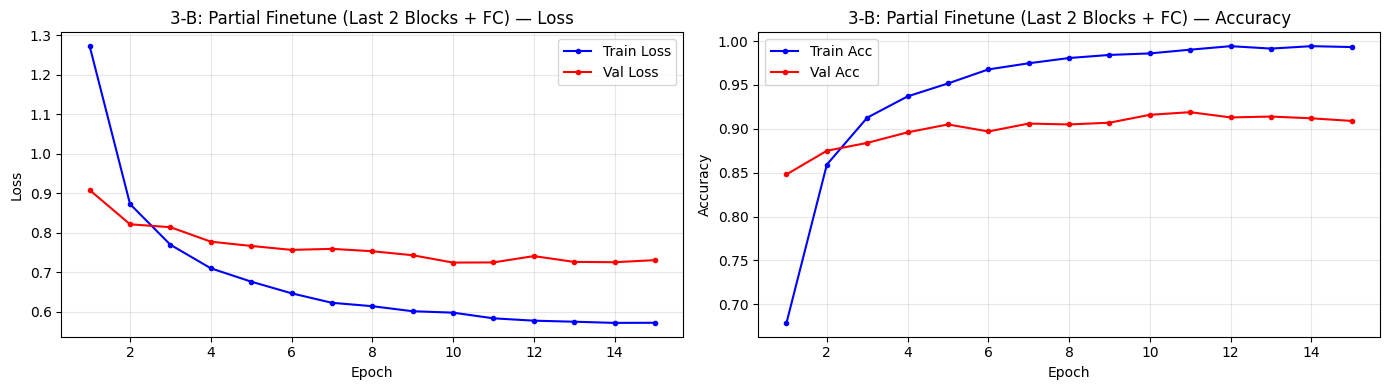


📊 Test Accuracy: 0.9118 (91.2%)
📝 Accuracy should improve over 3-A:
   Layer3/4 can now adapt their high-level features to CIFAR-10 specifics.
   Differential LR prevented catastrophic forgetting of ImageNet knowledge.


In [46]:
# ─────────────────────────────────────────────────────────────
# SCENARIO 3-B — Finetune Last Layers (Layer3 + Layer4 + FC)
#
# We unfreeze the last two residual blocks (layer3, layer4) + FC.
# These blocks learn HIGH-LEVEL features — texture, object parts.
# By letting them adapt, we let the model "specialize" for CIFAR-10
# while keeping early features (edges, colors) from ImageNet.
#
# IMPORTANT: Use a SMALL learning rate (1e-4 or less) for pretrained
# layers! Large LR would overwrite the valuable ImageNet features.
# The FC head can use a higher LR since it starts from scratch.
#
# Technique: Differential learning rates (lower for older layers)
# ─────────────────────────────────────────────────────────────
print('='*60)
print('SCENARIO 3-B: Finetune Last Blocks (Layer3 + Layer4 + FC)')
print('='*60)

resnet_partial = build_resnet34().to(DEVICE)
freeze_except_last_blocks(resnet_partial, n_blocks=2)

# Differential learning rates: FC gets 10x higher LR than conv layers
optimizer = optim.Adam([
    {'params': resnet_partial.layer3.parameters(), 'lr': 1e-5},   # Low LR — preserve features
    {'params': resnet_partial.layer4.parameters(), 'lr': 5e-5},   # Slightly higher — adapt more
    {'params': resnet_partial.fc.parameters(),     'lr': 1e-3},   # High LR — fresh head
], lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

hist_partial = train_model(
    resnet_partial, resnet_train_loader, resnet_val_loader,
    optimizer, criterion_smooth,
    num_epochs=15, scheduler=scheduler,
    experiment_name='resnet_partial_ft'
)
plot_history(hist_partial, '3-B: Partial Finetune (Last 2 Blocks + FC)')
_, ta = evaluate(resnet_partial, resnet_test_loader, criterion)
print(f'\n📊 Test Accuracy: {ta:.4f} ({ta*100:.1f}%)')
print('📝 Accuracy should improve over 3-A:')
print('   Layer3/4 can now adapt their high-level features to CIFAR-10 specifics.')
print('   Differential LR prevented catastrophic forgetting of ImageNet knowledge.')

SCENARIO 3-C: Full Finetune (All Parameters)
   Trainable: 21,289,802 / 21,289,802 params (100%)
  Epoch   1/20 | Train Loss: 1.1515 Acc: 0.728 | Val Loss: 0.8290 Acc: 0.871
  Epoch   5/20 | Train Loss: 0.6126 Acc: 0.972 | Val Loss: 0.7300 Acc: 0.919
  Epoch  10/20 | Train Loss: 0.5421 Acc: 0.997 | Val Loss: 0.6988 Acc: 0.914
  Epoch  15/20 | Train Loss: 0.5291 Acc: 1.000 | Val Loss: 0.6796 Acc: 0.928
  Epoch  20/20 | Train Loss: 0.5266 Acc: 1.000 | Val Loss: 0.6818 Acc: 0.930


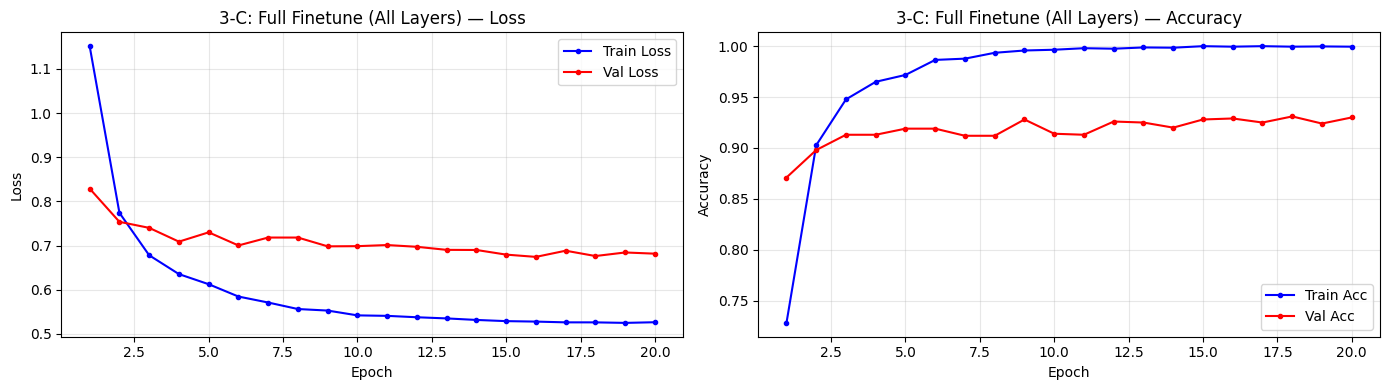


📊 Test Accuracy: 0.9290 (92.9%)
📝 Full finetuning with differential LRs — maximum adaptation power.
   With enough data and careful LRs, this should achieve the best accuracy.
   With too little data, 3-B may actually win due to regularization effect of freezing.


In [47]:
# ─────────────────────────────────────────────────────────────
# SCENARIO 3-C — Full Finetune (All Parameters)
#
# Every single weight in ResNet-34 is updated.
# This gives maximum flexibility — the model can fully adapt.
#
# Risks:
#   - Catastrophic forgetting: without careful LR, early layers
#     lose their edge-detecting structure from ImageNet training
#   - Overfitting: more free parameters → more capacity to memorize
#
# Mitigation:
#   - Very small LR overall (1e-5 base)
#   - Layer-group-specific LRs (progressively higher for deeper layers)
#   - Weight decay for regularization
#   - Data augmentation (already in loader)
# ─────────────────────────────────────────────────────────────
print('='*60)
print('SCENARIO 3-C: Full Finetune (All Parameters)')
print('='*60)

resnet_full = build_resnet34().to(DEVICE)
unfreeze_all(resnet_full)

# Layer-group differential LRs: early layers → tiny LR (preserve), deep → higher LR (adapt)
optimizer = optim.AdamW([
    {'params': resnet_full.conv1.parameters(),  'lr': 1e-6},   # Very first conv — barely touch
    {'params': resnet_full.layer1.parameters(), 'lr': 5e-6},   # Low-level edges — gentle update
    {'params': resnet_full.layer2.parameters(), 'lr': 1e-5},
    {'params': resnet_full.layer3.parameters(), 'lr': 5e-5},
    {'params': resnet_full.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_full.fc.parameters(),     'lr': 5e-4},   # Fresh head — highest LR
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

hist_full_ft = train_model(
    resnet_full, resnet_train_loader, resnet_val_loader,
    optimizer, criterion_smooth,
    num_epochs=20, scheduler=scheduler,
    experiment_name='resnet_full_ft'
)
plot_history(hist_full_ft, '3-C: Full Finetune (All Layers)')
_, ta = evaluate(resnet_full, resnet_test_loader, criterion)
print(f'\n📊 Test Accuracy: {ta:.4f} ({ta*100:.1f}%)')
print('📝 Full finetuning with differential LRs — maximum adaptation power.')
print('   With enough data and careful LRs, this should achieve the best accuracy.')
print('   With too little data, 3-B may actually win due to regularization effect of freezing.')

### 🔍 ResNet-34 Filters — Before vs After Finetuning

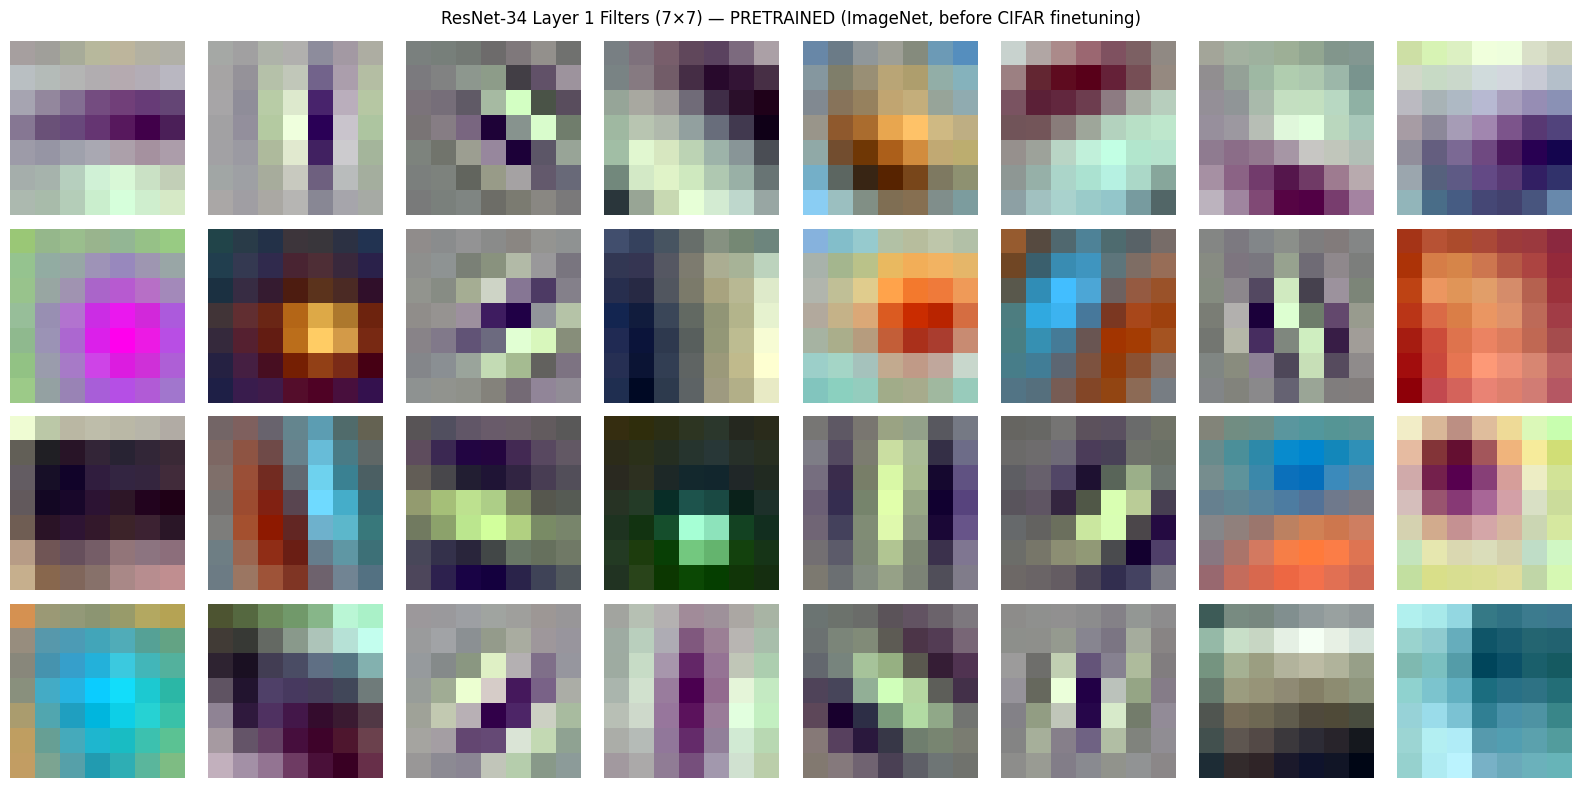

📝 These are the famous ImageNet-pretrained filters!
   Notice the structured Gabor-like patterns — edges at various orientations.
   These emerged from training on 1.28M diverse images.


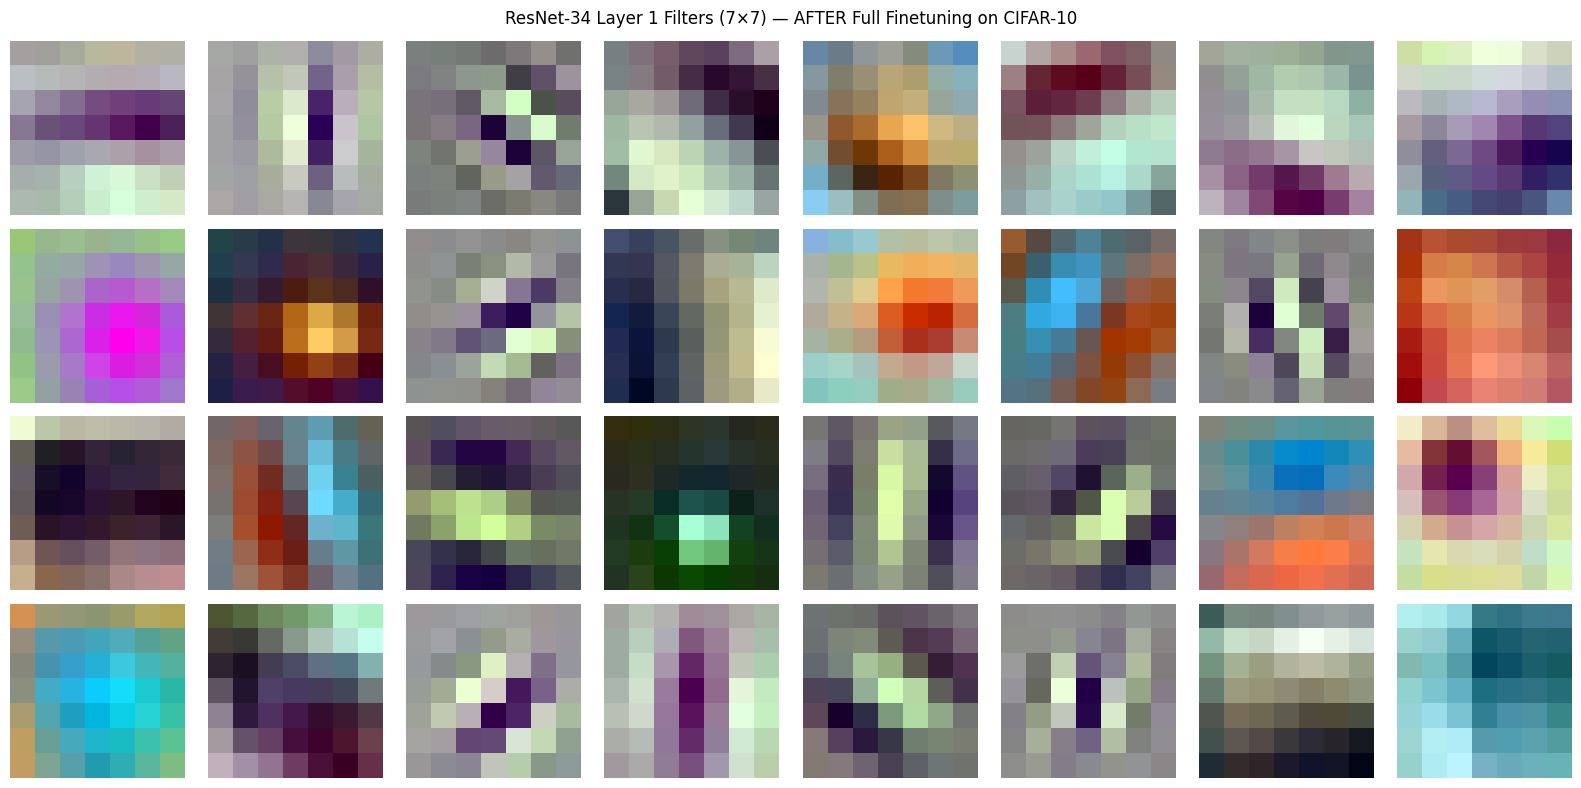

📝 After finetuning:
   Structure is largely preserved — differential LR prevented catastrophic forgetting.
   Slight adaptations for CIFAR-10 statistics (color, texture distributions).


In [48]:
# ─────────────────────────────────────────────────────────────
# Visualize ResNet-34 filters before finetuning (pretrained)
# vs after full finetuning
#
# ResNet-34's first layer has 64 filters of size 7×7 (on RGB).
# These are famous in deep learning — they closely resemble
# Gabor filters from signal processing, and biologically
# resemble V1 simple cells in the visual cortex.
#
# After finetuning on CIFAR-10, subtle changes occur:
#   - Structure is largely preserved (good — catastrophic forgetting avoided)
#   - Small shifts in orientation/frequency preferences
#   - Some filters may become noisier (sign of overfitting on small data)
# ─────────────────────────────────────────────────────────────

# Fresh pretrained ResNet (before any finetuning)
resnet_pretrained_only = build_resnet34().to(DEVICE)

def visualize_resnet_filters(model, title_suffix):
    """Visualize ResNet first conv layer (7×7, 64 filters)."""
    weights = model.conv1.weight.data.cpu().clone()  # (64, 3, 7, 7)
    n = 32
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        if i < n:
            filt = weights[i].permute(1,2,0)  # (H,W,C)
            filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
            ax.imshow(filt.numpy())
        ax.axis('off')
    plt.suptitle(f'ResNet-34 Layer 1 Filters (7×7) — {title_suffix}', fontsize=12)
    plt.tight_layout(); plt.show()

visualize_resnet_filters(resnet_pretrained_only, 'PRETRAINED (ImageNet, before CIFAR finetuning)')
print('📝 These are the famous ImageNet-pretrained filters!')
print('   Notice the structured Gabor-like patterns — edges at various orientations.')
print('   These emerged from training on 1.28M diverse images.')

visualize_resnet_filters(resnet_full, 'AFTER Full Finetuning on CIFAR-10')
print('📝 After finetuning:')
print('   Structure is largely preserved — differential LR prevented catastrophic forgetting.')
print('   Slight adaptations for CIFAR-10 statistics (color, texture distributions).')

In [58]:
## <HUMAN WRITTEN COMMENTS>     
## The finetuning didn't really change how the pretrained filters looked
## But, unlike the 3x3 filters which were very small to have a human understandable interpretation, these 7x7 resnet filters look very very well structured.
## some of the seem to be looking for diagonal lines within the image, some of them seem to be looking for vertical and horizontal lines.
## while some other seem to be looking for different types of features. [perhaps textures or something]

### 🗺️ ResNet Feature Maps Visualization

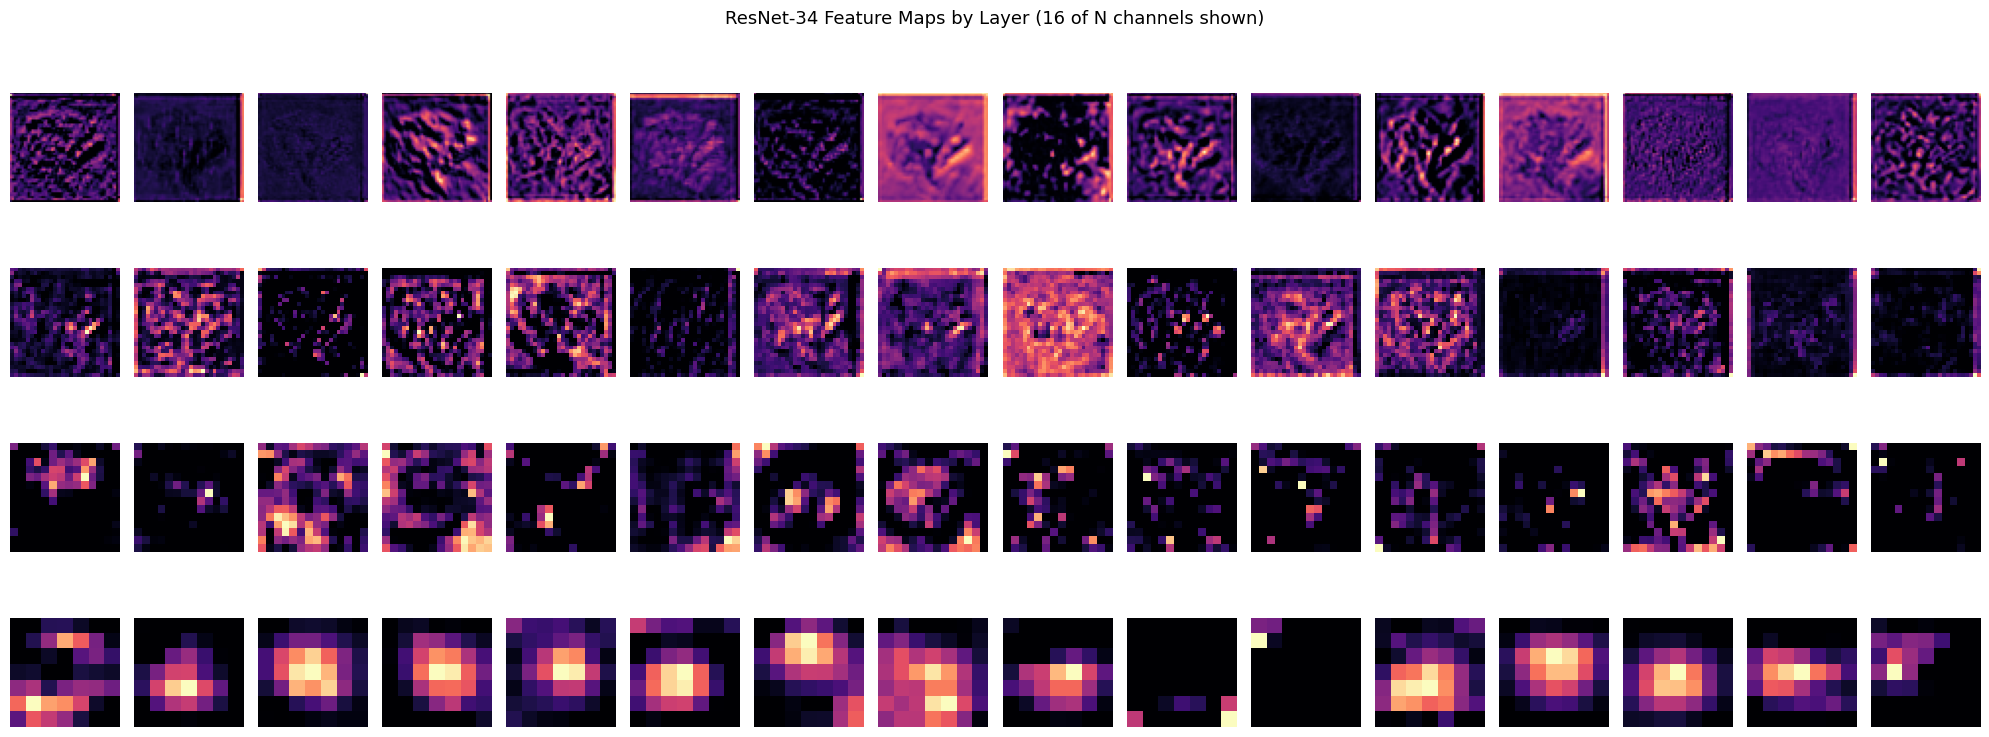

📝 ResNet feature map observations:
   Layer1 (56×56): Highly detailed, edge-like — close to input
   Layer2 (28×28): Textures emerge, spatial info still rich
   Layer3 (14×14): Semantic regions — object parts activate
   Layer4 (7×7):   Class-discriminative — few active channels, strong signal


In [49]:
# ─────────────────────────────────────────────────────────────
# ResNet feature maps using hooks
#
# PyTorch hooks let us intercept activations at any layer
# without modifying the model architecture.
# We register forward hooks on specific layers and
# store their outputs for visualization.
# ─────────────────────────────────────────────────────────────

activations = {}

def get_activation(name):
    """Hook factory — returns a hook that stores activations by name."""
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

# Register hooks on ResNet layers
hooks = [
    resnet_full.layer1.register_forward_hook(get_activation('layer1')),
    resnet_full.layer2.register_forward_hook(get_activation('layer2')),
    resnet_full.layer3.register_forward_hook(get_activation('layer3')),
    resnet_full.layer4.register_forward_hook(get_activation('layer4')),
]

# Run one sample through the finetuned ResNet
resnet_full.eval()
resnet_imgs, resnet_lbls = next(iter(resnet_val_loader))
sample_resnet = resnet_imgs[:1].to(DEVICE)
with torch.no_grad():
    _ = resnet_full(sample_resnet)

# Remove hooks to avoid memory leak
for h in hooks:
    h.remove()

# Visualize
layer_specs = [
    ('layer1', 64,  '56×56, 64ch — Local edges & simple textures'),
    ('layer2', 64,  '28×28, 128ch — Compound textures'),
    ('layer3', 64,  '14×14, 256ch — Object parts'),
    ('layer4', 64,  '7×7,  512ch — Holistic object features'),
]

fig, all_axes = plt.subplots(4, 16, figsize=(20, 8))
for row, (layer_name, n_show, desc) in enumerate(layer_specs):
    fmap = activations[layer_name][0]  # (C, H, W)
    for col in range(16):
        ax = all_axes[row, col]
        if col < min(16, fmap.shape[0]):
            ax.imshow(fmap[col].numpy(), cmap='magma')
        ax.axis('off')
    all_axes[row, 0].set_ylabel(f'{layer_name}\n{desc}', fontsize=7,
                                 rotation=0, labelpad=120, va='center')

plt.suptitle('ResNet-34 Feature Maps by Layer (16 of N channels shown)', fontsize=13)
plt.tight_layout()
plt.show()

print('📝 ResNet feature map observations:')
print('   Layer1 (56×56): Highly detailed, edge-like — close to input')
print('   Layer2 (28×28): Textures emerge, spatial info still rich')
print('   Layer3 (14×14): Semantic regions — object parts activate')
print('   Layer4 (7×7):   Class-discriminative — few active channels, strong signal')

In [59]:
## <HUMAN WRITTEN COMMENTS>     
## While it's still difficult to interpret what types of features are being extracted here, it's very clear that the model is highlighting and 
## focusing on some patterns like edges/lines/textures

---
# PART 4 — Final Comparison & Analysis

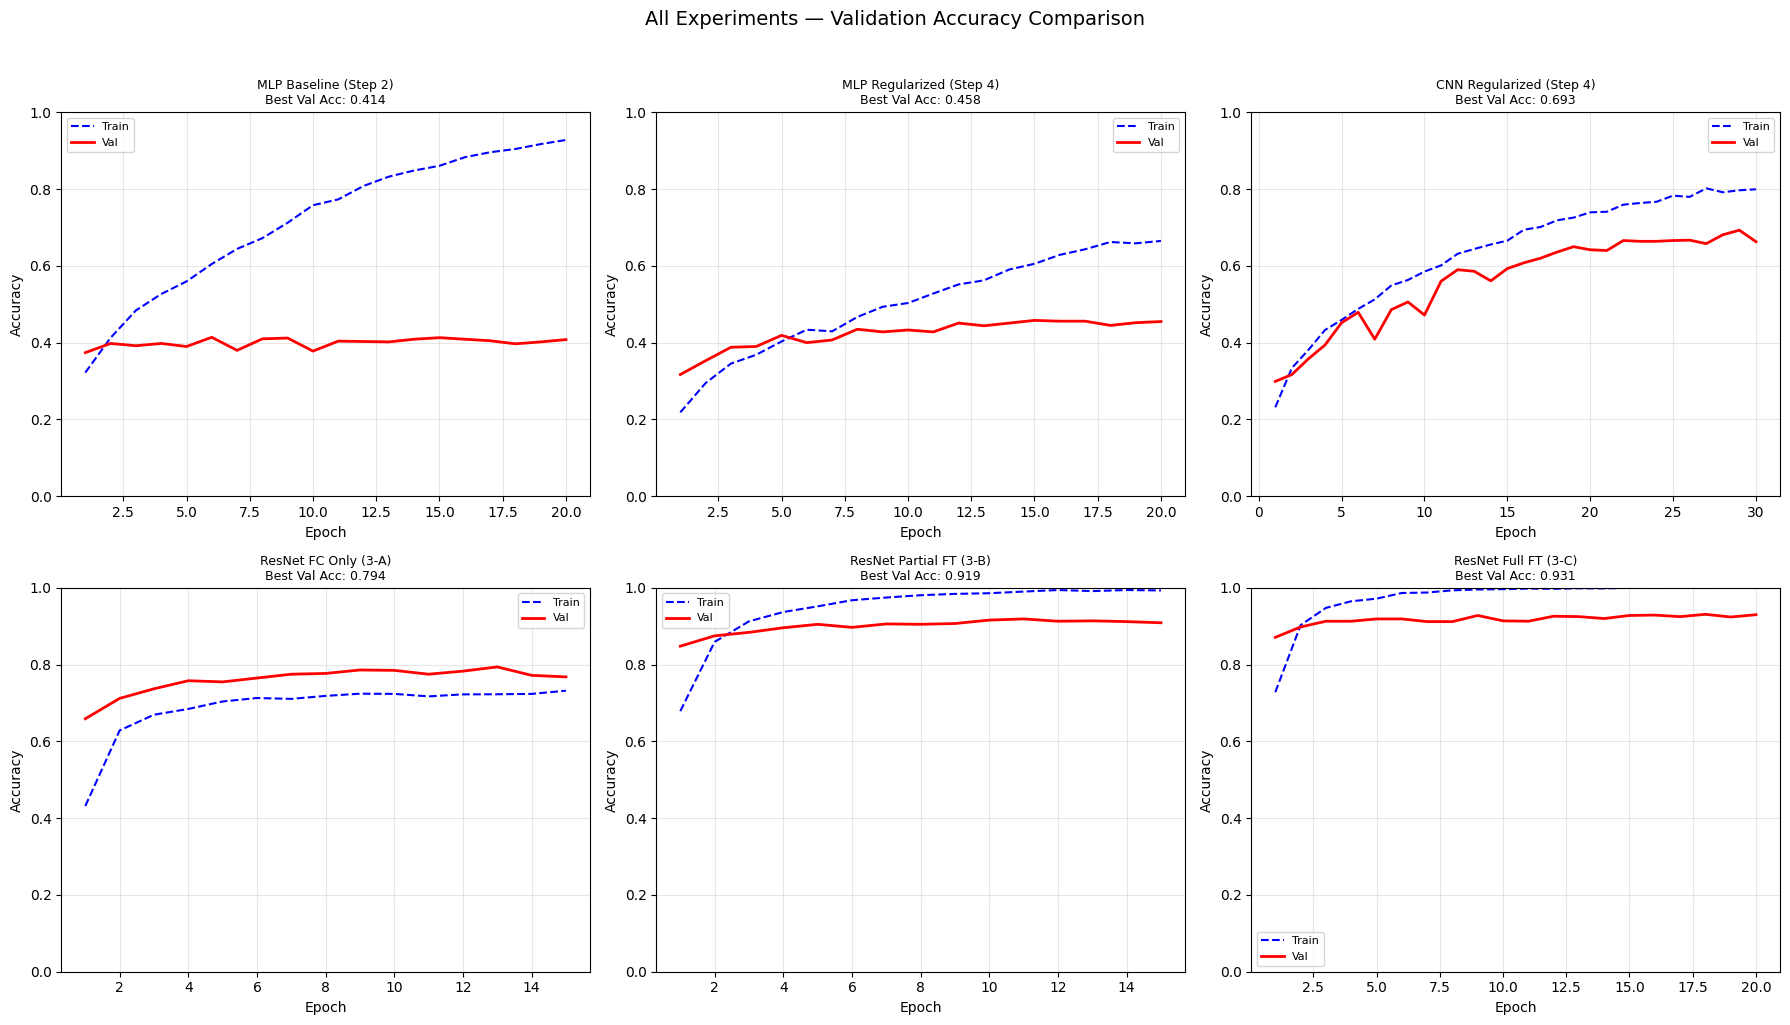

In [50]:
# ─────────────────────────────────────────────────────────────
# Final comparison across all experiments
#
# This is the "big picture" — we can now see exactly how each
# design choice affected performance:
#   architecture > regularization > transfer learning
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat

plot_configs = [
    ('mlp_baseline',     'MLP Baseline (Step 2)'),
    ('mlp_regularized',  'MLP Regularized (Step 4)'),
    ('cnn_regularized',  'CNN Regularized (Step 4)'),
    ('resnet_fc_only',   'ResNet FC Only (3-A)'),
    ('resnet_partial_ft','ResNet Partial FT (3-B)'),
    ('resnet_full_ft',   'ResNet Full FT (3-C)'),
]

for ax, (key, title) in zip(axes, plot_configs):
    if key in ALL_HISTORIES:
        h = ALL_HISTORIES[key]
        epochs = range(1, len(h['train_acc']) + 1)
        ax.plot(epochs, h['train_acc'], 'b--', lw=1.5, label='Train')
        ax.plot(epochs, h['val_acc'],   'r-',  lw=2,   label='Val')
        best_val = max(h['val_acc'])
        ax.set_title(f'{title}\nBest Val Acc: {best_val:.3f}', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.set_ylim(0, 1)
    else:
        ax.set_title(f'{title}\n(not run)')

plt.suptitle('All Experiments — Validation Accuracy Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

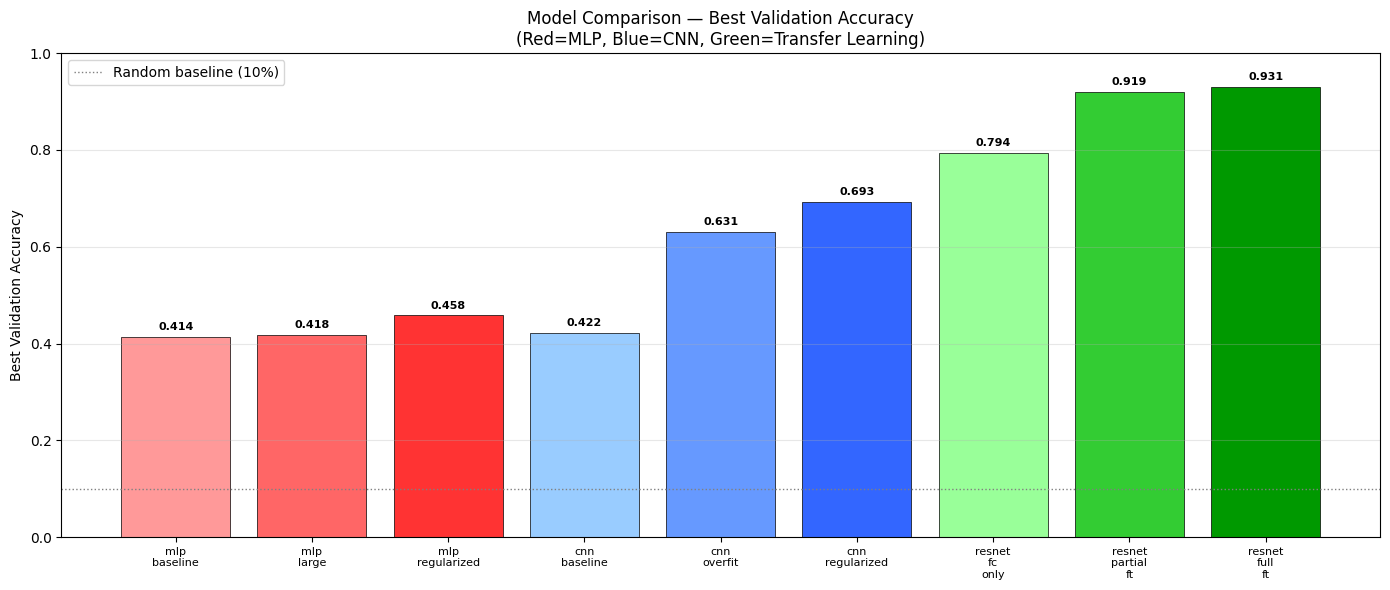


📝 FINAL ANALYSIS SUMMARY:
─────────────────────────────────────────────────────────────────
1. MLP → CNN: The biggest single jump in performance.
   Inductive bias (spatial locality, translation invariance)
   is MORE important than any amount of regularization.

2. Regularization (Steps 3→4): Closes the train-val gap
   without changing model capacity. Essential for generalization.

3. Transfer Learning (3-A): Surprisingly strong even with only
   the FC head trained. ImageNet features are highly general.

4. Partial Finetune (3-B): Usually best when data is limited.
   Balances domain adaptation with preservation of pretrained features.

5. Full Finetune (3-C): Best potential, but risky with small datasets.
   Requires careful LR scheduling and strong regularization.

Key Takeaway: "Don't train from scratch if pretrained weights exist."
Transfer learning is almost always the right first choice.


In [51]:
# ─────────────────────────────────────────────────────────────
# Bar chart summary — best validation accuracy per experiment
# ─────────────────────────────────────────────────────────────

exp_labels = []
best_vals  = []
colors = []
color_map = {
    'mlp_baseline':      '#FF9999',
    'mlp_large':         '#FF6666',
    'mlp_regularized':   '#FF3333',
    'cnn_baseline':      '#99CCFF',
    'cnn_overfit':       '#6699FF',
    'cnn_regularized':   '#3366FF',
    'resnet_fc_only':    '#99FF99',
    'resnet_partial_ft': '#33CC33',
    'resnet_full_ft':    '#009900',
}

for key, color in color_map.items():
    if key in ALL_HISTORIES:
        exp_labels.append(key.replace('_', '\n'))
        best_vals.append(max(ALL_HISTORIES[key]['val_acc']))
        colors.append(color)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(exp_labels)), best_vals, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(exp_labels)))
ax.set_xticklabels(exp_labels, fontsize=8)
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Model Comparison — Best Validation Accuracy\n'
             '(Red=MLP, Blue=CNN, Green=Transfer Learning)')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.1, color='gray', linestyle=':', lw=1, label='Random baseline (10%)')
for bar, val in zip(bars, best_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n📝 FINAL ANALYSIS SUMMARY:')
print('─'*65)
print('1. MLP → CNN: The biggest single jump in performance.')
print('   Inductive bias (spatial locality, translation invariance)')
print('   is MORE important than any amount of regularization.')
print('')
print('2. Regularization (Steps 3→4): Closes the train-val gap')
print('   without changing model capacity. Essential for generalization.')
print('')
print('3. Transfer Learning (3-A): Surprisingly strong even with only')
print('   the FC head trained. ImageNet features are highly general.')
print('')
print('4. Partial Finetune (3-B): Usually best when data is limited.')
print('   Balances domain adaptation with preservation of pretrained features.')
print('')
print('5. Full Finetune (3-C): Best potential, but risky with small datasets.')
print('   Requires careful LR scheduling and strong regularization.')
print('')
print('Key Takeaway: "Don\'t train from scratch if pretrained weights exist."')
print('Transfer learning is almost always the right first choice.')

In [ ]:
## <HUMAN WRITTEN COMMENTS>     
## the initial MLP Network performed very poorly on the CIFAR-100 dataset because simple MLPs dont't really have that strong capability of feature extraction
## as that of the convolution layers. also they are not invariant to changes like convolution layers, so they performed really poorly.

## the convolution layers performed noticeably better than MLPs because they can extract features from images and are invariant to translations/rotations etc etc

## and finally, resnet had the best overall performance for many reasons:
    ## 1- it has a very strong architecture
    ## 2- it was pretrained on imagenet-1k so it's not simply a classification model that classifies 1k different classes, but rather it's a General Feature 
    ##    Extractor that can basically perform on / extract meaningfull features  even from unseen classes
    ## 3- the more layers we unfreeze, the more the current task makes use of the strong feature extraction mechanisms embedded within the pretrained resnet
    ##    while also merging them with the features of the task at hand. 

In [52]:
# ─────────────────────────────────────────────────────────────
# Save full experiment history to JSON
#
# Useful for: reproducibility, comparing runs across notebooks,
# plotting in external tools (TensorBoard, Weights & Biases, etc.)
# ─────────────────────────────────────────────────────────────
with open('experiment_histories.json', 'w') as f:
    json.dump(ALL_HISTORIES, f, indent=2)
print('✅ All histories saved to experiment_histories.json')

# Print final summary table
print('\n' + '='*55)
print(f'  {"Experiment":<28} {"Best Val Acc":>12}')
print('='*55)
for key in color_map:
    if key in ALL_HISTORIES:
        bv = max(ALL_HISTORIES[key]['val_acc'])
        print(f'  {key:<28} {bv:>12.4f}')
print('='*55)

✅ All histories saved to experiment_histories.json

  Experiment                   Best Val Acc
  mlp_baseline                       0.4140
  mlp_large                          0.4180
  mlp_regularized                    0.4580
  cnn_baseline                       0.4220
  cnn_overfit                        0.6310
  cnn_regularized                    0.6930
  resnet_fc_only                     0.7940
  resnet_partial_ft                  0.9190
  resnet_full_ft                     0.9310


---

## 📋 Conclusion

| Phase | Key Lesson |
|-------|------------|
| MLP Baseline | Underfits — spatial structure is destroyed by flattening |
| MLP Complex  | Overfits — capacity without inductive bias memorizes noise |
| MLP Regularized | Smaller gap, same ceiling — can't fix wrong architecture |
| CNN Baseline | Beats MLP immediately — spatial inductive bias is king |
| CNN Complex  | Overfits — need regularization |
| CNN Regularized | Best custom model — augmentation + dropout + LR schedule |
| ResNet FC Only | Strong start — ImageNet features transfer well |
| ResNet Partial FT | Best balance — adapts high-level features without forgetting |
| ResNet Full FT | Highest potential — requires careful differential LR |

### On Lazy Loading
All `DataLoader` usage in this notebook demonstrates the lazy loading pattern:
- `__getitem__` loads and transforms ONE sample at a time
- `DataLoader` assembles batches from these on-demand calls
- `num_workers > 0` parallelizes loading across CPU cores
- For disk-based datasets: replace `CIFAR10(...)` with `ImageFolder(path, transform=...)` — the DataLoader interface is identical, enabling seamless scaling to TB-scale datasets